In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt


/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/

In [ ]:
1. DEGs between D1/D2 vs. Hybrid subclass per species among primates - Yuanyuan

2. Veen plot across species for up/down-regulated genes in Hybrids - Yuanyuan

3. highlight TF patterns [and will also check DNAseqModel results later - Nelson] - Yuanyuan

4. for core genes(overlapped up-regulated); do GO enrichment analysis - Yuanyuan

5. for human-specific higher genes, do GO analysis - Yuanyuan

6. any abundance changes betwen D1/D2 islands and Hybrid island across species (also, in primates vs. mouse) - Matthew?

Also,

1. within Hybrid subclass, what make D1D2 hyrbid Group distinct? conserved features across species.

2. within D1D2 hyrbid Group, DRD1/DRD2 expression fraction changes across species

3. Speaking of Hybrids, any conserved and divergent features between D1D2 Hyrbids group and D2StrioMat Group? - Matthew?

Also, 

how do ATAC/Model best fit in?

In [2]:
#data_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/data/xspecies"

work_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/Hybrids/D1D2vsHyrbids_Subclass"
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

In [3]:
adata = sc.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter" + "/temp_consensus_preprint_3species_adata_withlogCPM_X.h5ad")

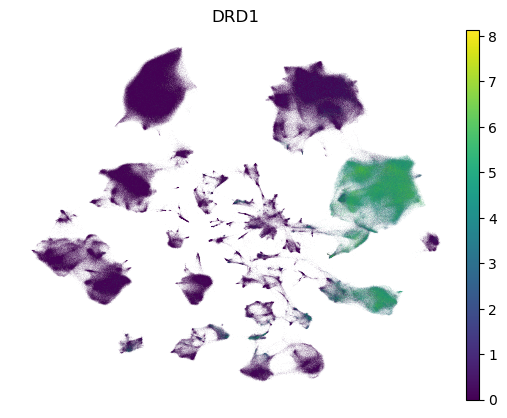

In [4]:
sc.pl.embedding(
    adata,
    basis="X_umap",
    color=['DRD1'],
    frameon=False,
)

## subsetting MSNs

In [4]:
set(adata.obs['Subclass'])

{'ACx MEIS2 GABA',
 'Astrocyte',
 'CN Cholinergic GABA',
 'CN GABA-Glut',
 'CN LAMP5-CXCL14 GABA',
 'CN LAMP5-LHX6 GABA',
 'CN LHX8 GABA',
 'CN MEIS2 GABA',
 'CN ONECUT1 GABA',
 'CN ST18 GABA',
 'CN VIP GABA',
 'COP',
 'Endo',
 'Ependymal',
 'F GABA',
 'F Glut',
 'F M GATA3 GABA',
 'F M Glut',
 'Lymphocyte',
 'M Dopa',
 'Macrophage',
 'Microglia',
 'Monocyte',
 'OPC',
 'OT Granular GABA',
 'Oligodendrocyte',
 'Pericyte',
 'SMC',
 'SN PAX7 GABA',
 'STR D1 MSN',
 'STR D2 MSN',
 'STR Hybrid MSN',
 'STR RSPO2 GABA',
 'STR SST GABA',
 'STR SST-CHODL GABA',
 'VLMC'}

In [5]:
#selected = ["STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN"]
selected = ["STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN", "OT Granular GABA"]
adata_msn = adata[adata.obs["Subclass"].isin(selected)].copy()


In [6]:
#adata_msn.write_h5ad("Consensus_preprint_3species_MSNs_withlogCPM_X.h5ad") #9 groups
adata_msn.write_h5ad("Consensus_preprint_3species_MSNs-ICj_withlogCPM_X.h5ad") #10 groups

In [3]:
adata_msn=sc.read_h5ad("Consensus_preprint_3species_MSNs-ICj_withlogCPM_X.h5ad") #10 groups

In [14]:
set(adata.obs['organism'])

{'Human', 'Macaque', 'Marmoset'}

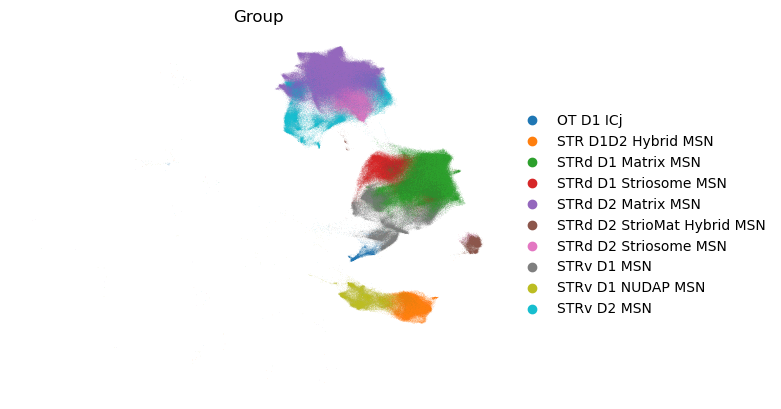

In [7]:
sc.pl.embedding(
    adata_msn,
    basis="X_umap",
    color=['Group'],
    frameon=False,
)

In [10]:
group_order = ['OT D1 ICj', 'STRv D1 MSN', 'STRd D1 Striosome MSN', 'STRd D1 Matrix MSN', 'STRv D2 MSN', 'STRd D2 Striosome MSN', 'STRd D2 Matrix MSN', 'STRd D2 StrioMat Hybrid MSN', 'STR D1D2 Hybrid MSN', 'STRv D1 NUDAP MSN']
adata_msn.obs['Group'] = pd.Categorical(adata_msn.obs['Group'],
                                          categories=group_order,
                                          ordered=True)

## for fig3. panel A (10 Groups here)

### gene list from He et al & what we've known or used as markers

In [29]:
marker_list_he= ['DRD1', 'TAC1', 'DRD2', 'PENK', 'CPNE4', 'ARHGAP6', 'GRIA4', 'KCNIP1', 'STXBP6', 'RXFP1', 'FOXP2', 'TSHZ1', 'CASZ1', 'GRIK1']

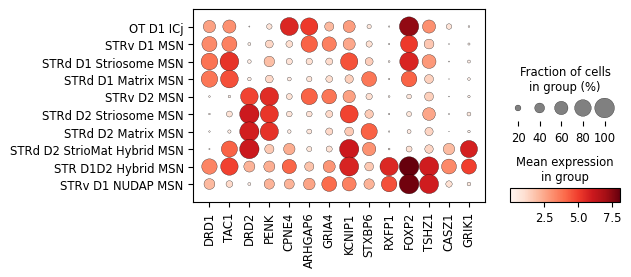

In [30]:
sc.pl.dotplot(
    adata_msn,
    var_names=marker_list_he, 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)


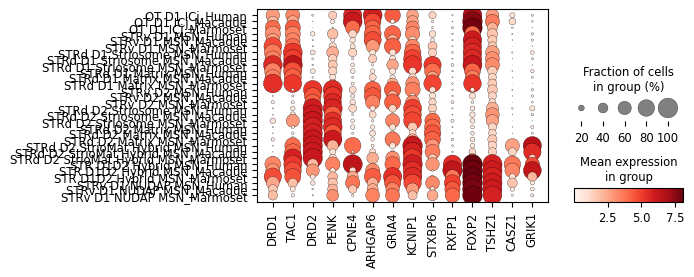

In [69]:
sc.pl.dotplot(
    adata_msn,
    var_names=marker_list_he, 
    groupby=["Group", 'organism'], 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)


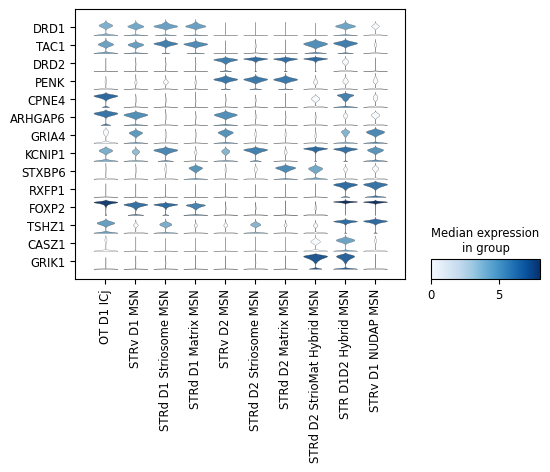

In [32]:
sc.pl.stacked_violin(
    adata_msn, 
    marker_list_he, 
    groupby='Group', 
    use_raw=False, 
    swap_axes=True, 
    figsize=(6,3.5),
    #cmap='rainbow', #Blues
    dendrogram=False,
   # save="Violinplot_of_AstroMarkers_fig2.pdf"
)

### TFs

In [6]:
df_tfs = pd.read_csv("/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/Human/BasalGanglia/analysis/f1" + "/TFs_lambert_pmid29425488_1.01.txt")
tf_genes = set(df_tfs["hgnc_symbol"]) 
#tf_genes

### gene list from the primate whole taxonomy expr/tau analysis

In [8]:
df = pd.read_csv("/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/expressologs/group/group_expressologs_auroc_tau_metrics.csv")

In [9]:
df

,gene,human,macaque,marmoset,xspecies_mean,xspecies_median,xspecies_min,xspecies_max,xspecies_recurrence,species1,species2,sp1_expr_stat,sp2_expr_stat,expr_cor,sp_order,median_cor,rank,auroc
0,A1BG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,marmoset,human,0.014842,0.120798,-0.133270,1,0.089677,1591,0.095670
1,A1BG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,macaque,human,0.078034,0.120798,0.089677,1,0.089677,1591,0.095670
2,A1BG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,marmoset,macaque,0.014842,0.078034,0.521229,2,0.089677,1591,0.095670
3,A1BG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,human,macaque,0.120798,0.078034,0.089677,2,0.089677,1591,0.095670
4,A1BG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,macaque,marmoset,0.078034,0.014842,0.521229,1,0.089677,1591,0.095670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99721,ZZEF1,0.328245,0.289661,0.348992,0.322299,0.328245,0.289661,0.348992,0.0,marmoset,human,1.327776,0.841711,0.614672,1,0.614672,10486,0.630547
99722,ZZEF1,0.328245,0.289661,0.348992,0.322299,0.328245,0.289661,0.348992,0.0,human,marmoset,0.841711,1.327776,0.614672,2,0.614672,10486,0.630547
99723,ZZEF1,0.328245,0.289661,0.348992,0.322299,0.328245,0.289661,0.348992,0.0,macaque,human,1.176036,0.841711,0.472288,1,0.614672,10486,0.630547
99724,ZZEF1,0.328245,0.289661,0.348992,0.322299,0.328245,0.289661,0.348992,0.0,human,macaque,0.841711,1.176036,0.472288,2,0.614672,10486,0.630547


In [33]:
filtered_df = df[(df["xspecies_min"] > 0.75) & (df["auroc"] > 0.75)]
unique_genes = filtered_df["gene"].unique().tolist()

print(len(unique_genes))
print(unique_genes)

941
['A4GALT', 'ABCA8', 'ABCB1', 'ABCC9', 'ABCG2', 'ABTB2', 'ACAN', 'ACKR3', 'ACSBG1', 'ACSF2', 'ACSS1', 'ACSS3', 'ACTA2', 'ACTG2', 'ACVRL1', 'ADAM28', 'ADAM7', 'ADAMTS1', 'ADAMTS2', 'ADAMTS3', 'ADAMTS4', 'ADAP2', 'ADCY4', 'ADCYAP1', 'ADGB', 'ADGRA2', 'ADGRF5', 'ADGRL4', 'ADIRF', 'ADORA2A', 'AFAP1L1', 'AFAP1L2', 'AGBL2', 'AGT', 'AHNAK', 'AHNAK2', 'AIF1L', 'AIFM3', 'AK1', 'AK7', 'AKAIN1', 'AKAP14', 'AKAP5', 'ALDH1A1', 'ALDH1A3', 'ALOX5AP', 'AMIGO2', 'ANKRD66', 'ANKRD9', 'ANLN', 'ANO1', 'ANXA1', 'APOD', 'APOE', 'APOLD1', 'AQP4', 'ARHGAP29', 'ARHGAP42', 'ARHGEF26', 'ARMC3', 'ARMC4', 'ARX', 'ASAH2', 'ASB4', 'ASCL1', 'ASIC4', 'ASPA', 'ATP10A', 'ATP10B', 'ATP1A2', 'AXDND1', 'BARX2', 'BCAM', 'BCAN', 'BCAS1', 'BDNF', 'BGN', 'BIN2', 'BLNK', 'BMP5', 'BMP7', 'BNC2', 'BSPRY', 'C10H3orf18', 'C10H6orf141', 'C13H22orf15', 'C15H16orf89', 'C16H10orf90', 'C16H1orf198', 'C1H1orf141', 'C1H1orf87', 'C1QA', 'C1QB', 'C1QC', 'C1QL1', 'C1QL3', 'C3', 'C4H21orf91', 'C5H4orf19', 'C7', 'C8H11orf96', 'C9H7orf57', '

In [35]:
expr_tau_tf = list(set(unique_genes) & set(tf_genes))
print(len(expr_tau_tf))
print(expr_tau_tf)

114
['TBR1', 'TBX2', 'LEF1', 'OLIG1', 'ZNF503', 'LHX2', 'RFX2', 'NPAS1', 'SALL3', 'DLX1', 'ONECUT2', 'FOXA1', 'FOXJ1', 'TCF7L1', 'CREB5', 'LHX8', 'ONECUT1', 'FOSL2', 'POU3F4', 'NKX6-2', 'NFATC2', 'NR2F1', 'GBX1', 'LHX9', 'TP73', 'KLF4', 'SOX4', 'CEBPD', 'POU3F1', 'ZIC3', 'LMX1A', 'ZNF488', 'GATA2', 'MAF', 'FOXO6', 'GATA3', 'TEAD4', 'TBX18', 'NKX2-1', 'FOXD1', 'KLF5', 'MECOM', 'ZNF831', 'FOXQ1', 'FLI1', 'NFIX', 'ERG', 'EBF1', 'RXRG', 'YBX3', 'ESRRB', 'SP8', 'SOX1', 'ST18', 'BNC2', 'GLI3', 'NKX2-2', 'ZIC2', 'MAFB', 'SOX10', 'MEIS1', 'LHX6', 'PRDM16', 'HNF4G', 'TBX15', 'HEY2', 'HEYL', 'ZNF366', 'ETS1', 'SIM2', 'ISL1', 'LMX1B', 'PITX2', 'PAX6', 'PROX1', 'CREB3L1', 'BARX2', 'RREB1', 'TBX3', 'NR4A2', 'SCX', 'ZIC4', 'ASCL1', 'PRDM8', 'SP9', 'RORB', 'OLIG2', 'HES1', 'DBX2', 'OTX2', 'POU3F2', 'KLF2', 'EN1', 'EPAS1', 'SALL1', 'FOXC1', 'ARX', 'EBF3', 'LHX1', 'SOX18', 'NHLH2', 'MYRF', 'TWIST1', 'IRF8', 'ZIC1', 'SIX3', 'TAL1', 'FOXA2', 'ETV1', 'PRRX1', 'TFEC', 'UNCX', 'NR2F2', 'LHX5']


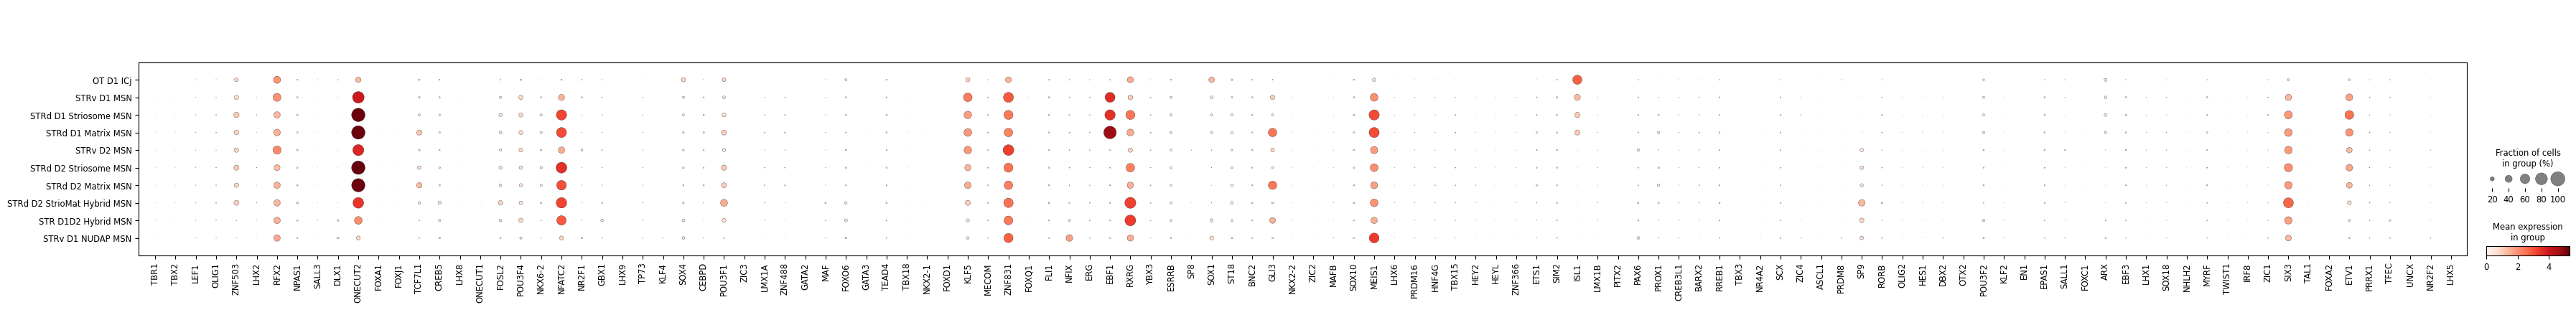

In [36]:
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_tf, 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)


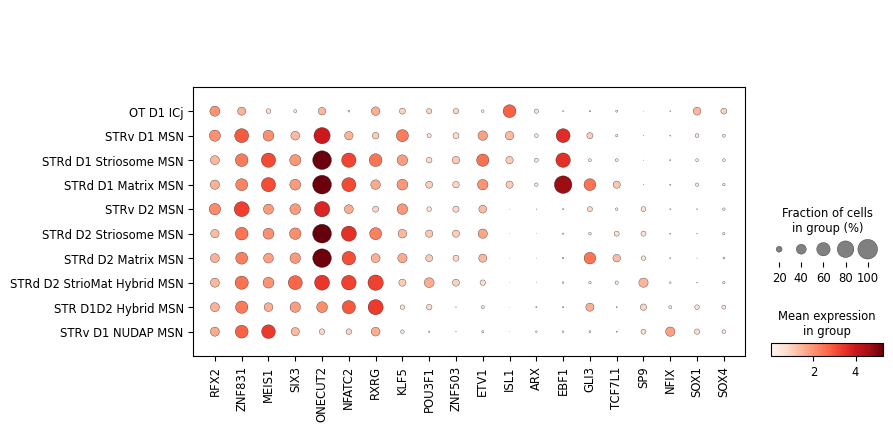

In [39]:
expr_tau_tf_curated = ['RFX2','ZNF831','MEIS1', 'SIX3', 'ONECUT2', 'NFATC2', 'RXRG',  #pan
                       'KLF5', 'POU3F1', 'ZNF503', 'ETV1', 
                       'ISL1','ARX','EBF1', # DRD1
                       'GLI3', 'TCF7L1',  # Matrix
                       'SP9',  # not classic DRD1 
                       'NFIX',  'SOX1', 'SOX4',
                        ]
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_tf_curated, 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

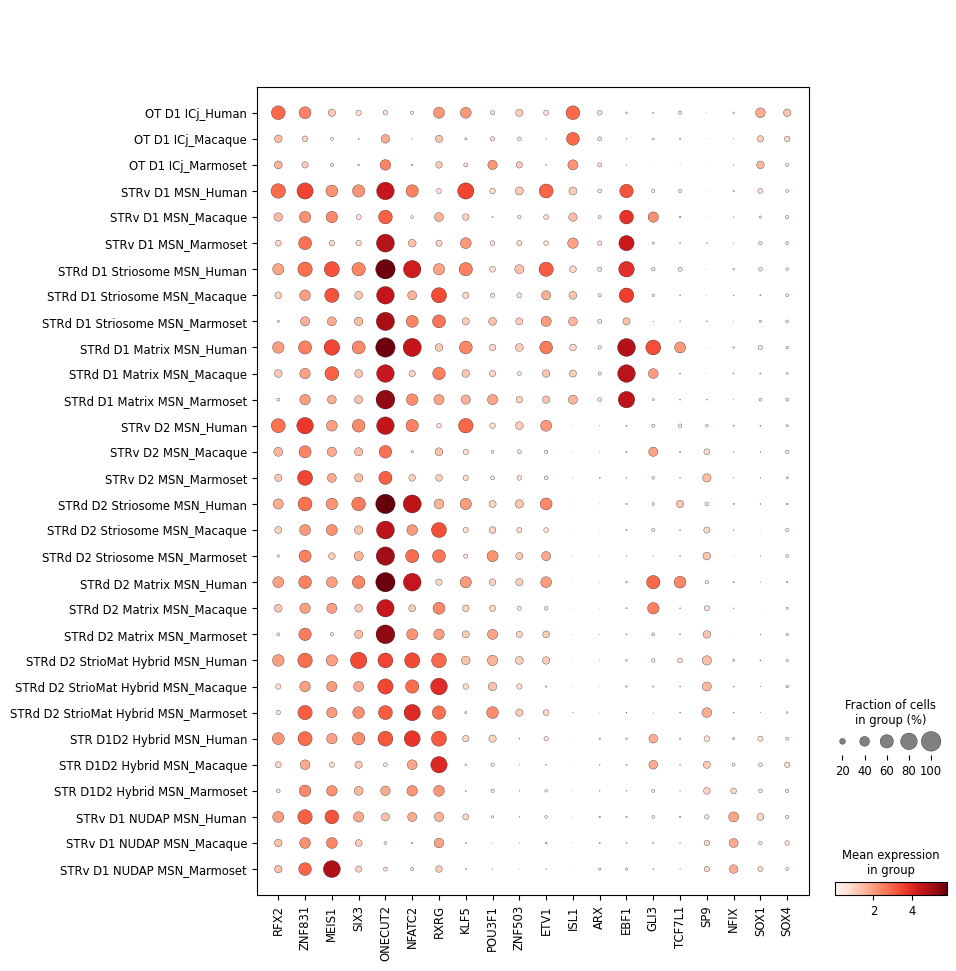

In [68]:
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_tf_curated, 
    groupby=["Group", "organism"], 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

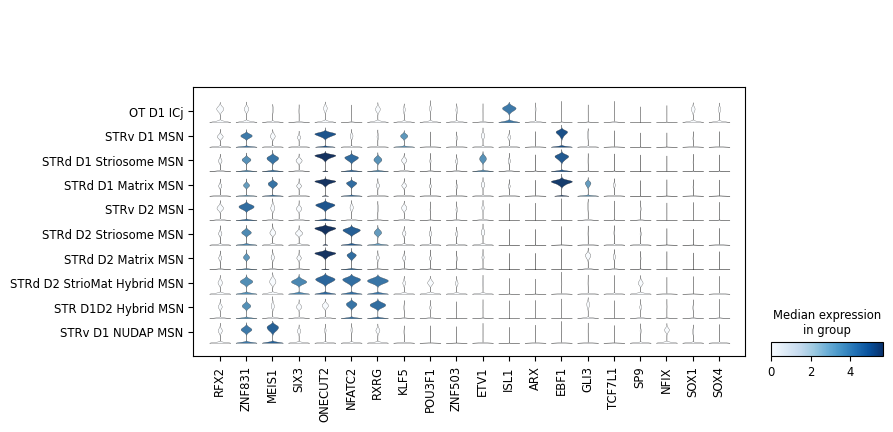

In [41]:
sc.pl.stacked_violin(
    adata_msn, 
    expr_tau_tf_curated, 
    groupby='Group', 
    use_raw=False, 
    swap_axes=False, 
   # figsize=(6,3.5),
    #cmap='rainbow', #Blues
    dendrogram=False,
   # save="Violinplot_of_AstroMarkers_fig2.pdf"
)

##### filter genes by fraction & expression_level

In [50]:
from anndata import AnnData
from typing import Iterable, Tuple, List, Optional

def filter_genes_by_group_expression(
    adata: AnnData,
    genes: Iterable[str],
    group_key: str = "Group",
    layer: Optional[str] = None,
    frac_thresh: float = 0.2,
    mean_thresh: float = 1.0,
) -> Tuple[List[str], pd.DataFrame]:
    """
    Keep genes that satisfy, in at least one group:
      (fraction of cells with expr > 0) > frac_thresh  AND
      mean expression > mean_thresh.

    Speed/memory notes:
      - Work on sparse CSR and avoid densification.
      - Mean is computed as column-wise sum / n_cells, which is vectorized and fast.
    """
    # Select expression matrix (layer or X) and ensure CSR for efficient row slicing
    X = adata.layers[layer] if layer is not None else adata.X
    if not hasattr(X, "tocsr"):
        import scipy.sparse as sp
        X = sp.csr_matrix(X)
    else:
        X = X.tocsr()

    # Keep only genes present in adata.var_names
    genes = [g for g in genes if g in adata.var_names]
    if len(genes) == 0:
        return [], pd.DataFrame(columns=["gene", "group", "n_cells", "frac_expr_gt0",
                                         "mean", "pass_pair"])

    # Map genes to column indices
    gene_idx = adata.var_names.get_indexer(genes)

    # Ensure categorical grouping for consistent group order
    groups = adata.obs[group_key].astype("category")
    adata.obs[group_key] = groups
    group_cats = list(groups.cat.categories)

    records = []
    # Compute per-group metrics
    for g in group_cats:
        rows = (groups == g).values
        n = int(rows.sum())
        if n == 0:
            continue

        # Subset rows (cells of this group) and target gene columns
        sub = X[rows, :][:, gene_idx]  # (n_cells_in_group × n_genes)

        # Fraction expressing (>0), vectorized on sparse matrix
        frac_expr_gt0 = (sub > 0).sum(axis=0).A1 / n

        # Mean expression per gene over all cells: sum / n (no densification)
        mean_vals = sub.sum(axis=0).A1 / n

        # Pass rule for this (gene, group)
        pass_pair = (frac_expr_gt0 > frac_thresh) & (mean_vals > mean_thresh)

        # Collect tidy rows
        for j, gene in enumerate(genes):
            records.append({
                "gene": gene,
                "group": g,
                "n_cells": n,
                "frac_expr_gt0": frac_expr_gt0[j],
                "mean": mean_vals[j],
                "pass_pair": bool(pass_pair[j]),
            })

    details = pd.DataFrame.from_records(records)

    # Keep genes that pass in at least one group
    keep_mask = details.groupby("gene")["pass_pair"].any()
    kept_genes = keep_mask[keep_mask].index.tolist()

    # Optional: sort for inspection
    details = details.sort_values(["gene", "group"]).reset_index(drop=True)
    return kept_genes, details


In [51]:
gene_set = list(unique_genes)  
kept, per_group_metrics = filter_genes_by_group_expression(
    adata=adata_msn,
    genes=gene_set,
    group_key="Group",
    frac_thresh=0.15, # at least one Group that frac>0.15 & mean_th >1
    mean_thresh=1.0
)

print(f"Kept {len(kept)} / {len(gene_set)} genes")
per_group_metrics.query("pass_pair").head()


Kept 152 / 941 genes


,gene,group,n_cells,frac_expr_gt0,mean,pass_pair
22,ABCB1,STRd D1 Matrix MSN,221515,0.279945,1.134921,True
23,ABCB1,STRd D1 Striosome MSN,65028,0.336501,1.365729,True
25,ABCB1,STRd D2 StrioMat Hybrid MSN,13483,0.272269,1.051667,True
26,ABCB1,STRd D2 Striosome MSN,56647,0.283722,1.170870,True
27,ABCB1,STRv D1 MSN,81756,0.286205,1.171449,True


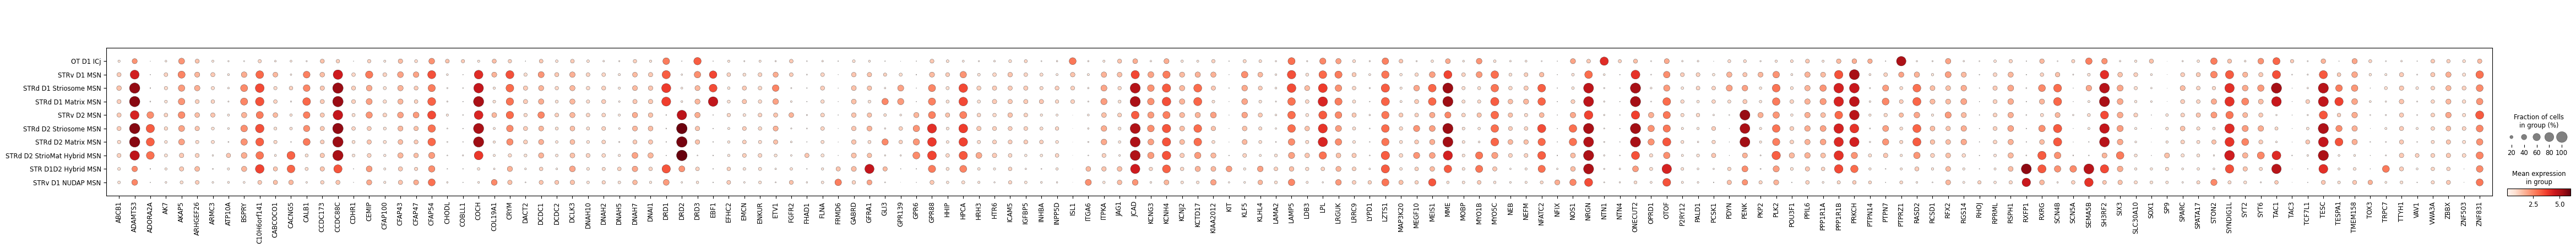

In [52]:
sc.pl.dotplot(
    adata_msn,
    var_names=kept, 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

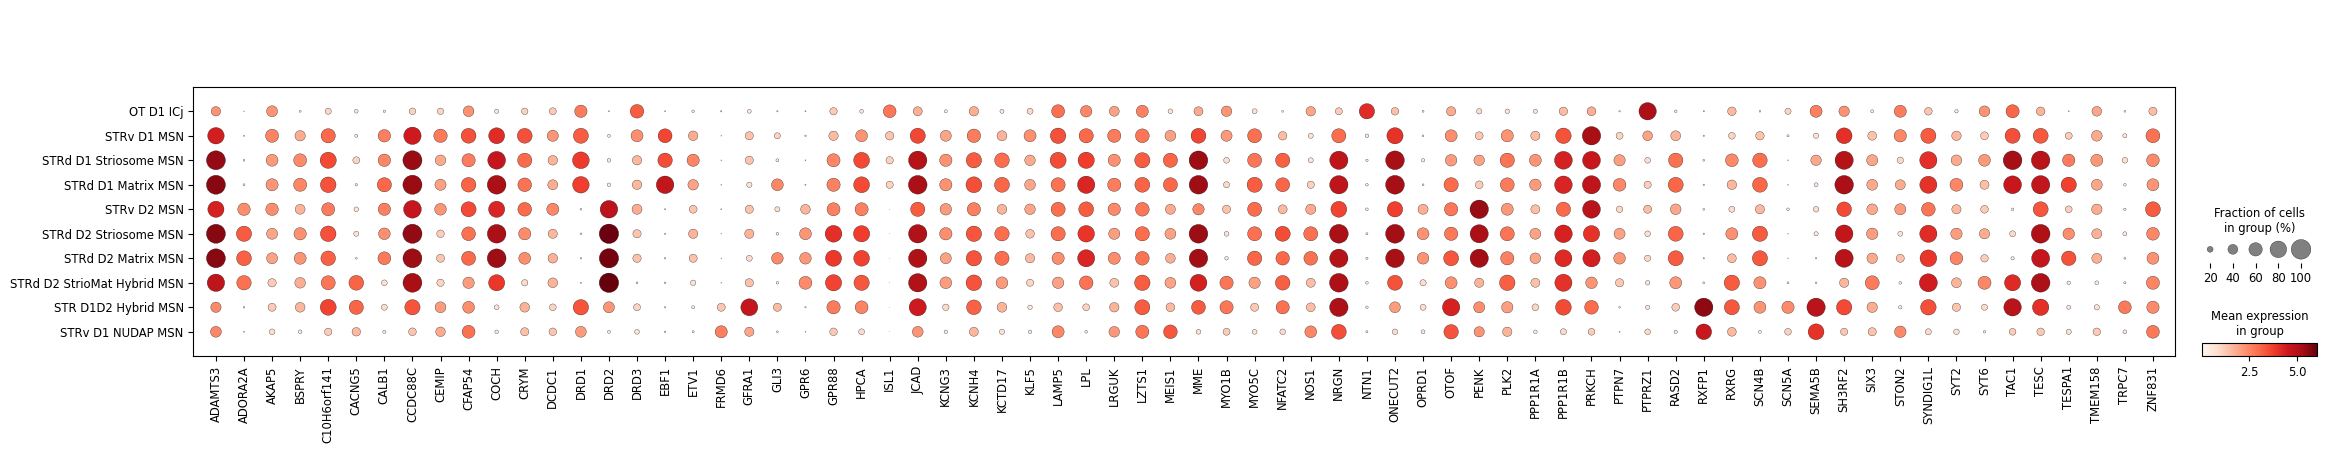

In [49]:
sc.pl.dotplot(
    adata_msn,
    var_names=kept, #median >1, frac>0.2 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

In [66]:
expr_tau_genes_curated= [
 'PTPRZ1', 'NTN1', 'NTN4', 'CHODL', 'COBLL1', 'TAC3', #ICJ
 'TMEM158', 'COCH', 'CALB1', 'ARMC3', 'CDHR1', 'DACT2', 'RGS14', 'ZNF503', #CLASSIC
 'DRD1','TAC1', 'PDYN', 'ISL1', 'EBF1',   #DRD1
 'DRD2', 'ADORA2A', 'GPR6', 'OPRD1', 'PENK', #DRD2
 'RXFP1', 'SEMA5B', 'FRMD6', 'ITGA6',  #HYBRID SUBCLASS
 'GFRA1', 'KIT', 'SCN5A', 'TRPC7', 'LAMA2', #D1D2 HYBRID GROUP
 'CACNG5', #2hyrbid groups
 'ATP10A', 'FHAD1', #D2StrioMat
 'DRD3', #not expressed in D2striomat 
 'TESPA1', 'PTPN7', 'GPR139', 'RCSD1', 'RASD2', 'SCN4B', #DORSAL MATRIX+STRIOSOME
 'MEGF10', 'RXRG','VAV1', #STRIO
 'GLI3', 'TCF7L1', # MATRIX
 'COL19A1', 'FGFR2', 'PKP2', #VENTRAL
 'LYPD1', 'NFIX', 'RHOJ', 'TOX3', #NUDAP
]
 

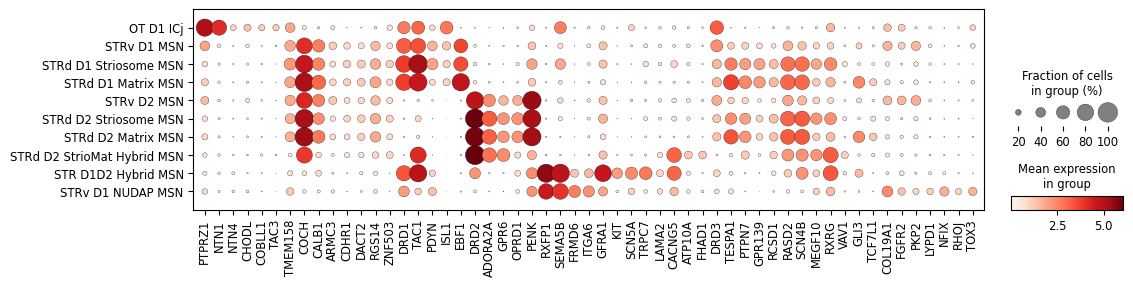

In [61]:
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_genes_curated, 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    figsize=(12, 2.6),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

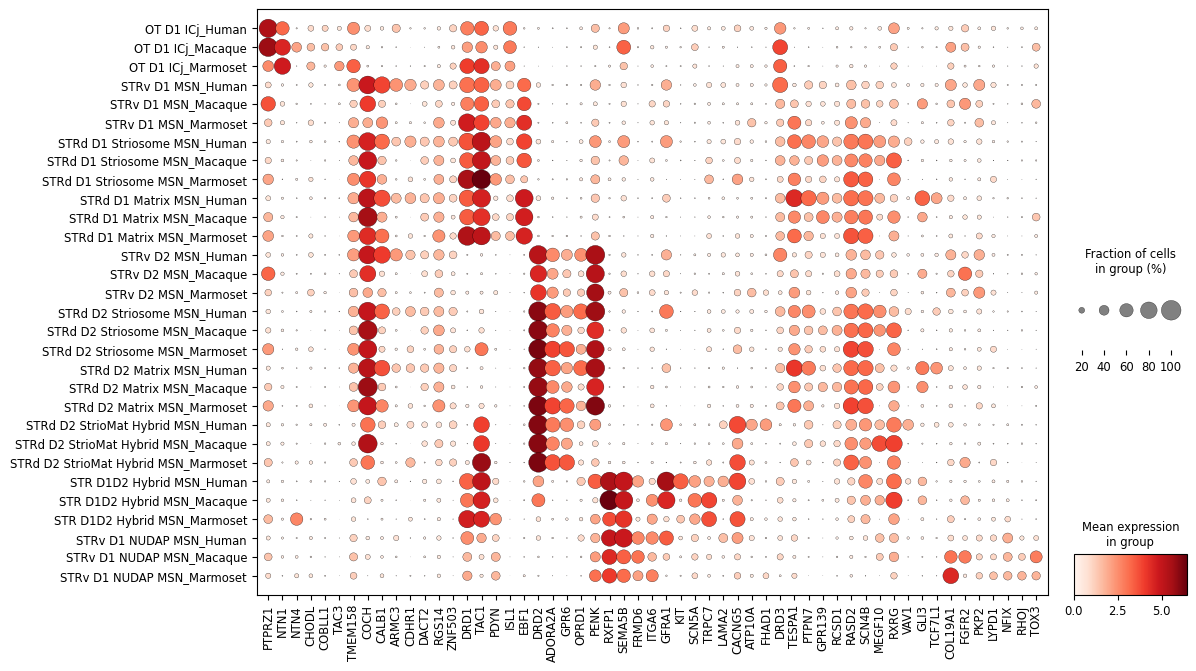

In [70]:
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_genes_curated, 
    groupby=["Group", 'organism'], 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    figsize=(12, 7.6),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

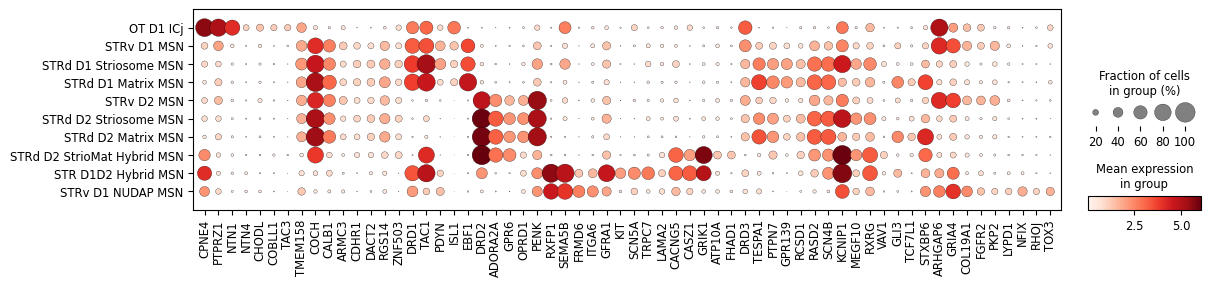

In [64]:
expr_tau_genes_curated_plus_known = [
 'CPNE4', 'PTPRZ1', 'NTN1', 'NTN4', 'CHODL', 'COBLL1', 'TAC3', #ICJ
 'TMEM158', 'COCH', 'CALB1', 'ARMC3', 'CDHR1', 'DACT2', 'RGS14', 'ZNF503', #CLASSIC
 'DRD1','TAC1', 'PDYN', 'ISL1', 'EBF1',   #DRD1
 'DRD2', 'ADORA2A', 'GPR6', 'OPRD1', 'PENK', #DRD2
 'RXFP1', 'SEMA5B', 'FRMD6', 'ITGA6',  #HYBRID SUBCLASS
 'GFRA1', 'KIT', 'SCN5A', 'TRPC7', 'LAMA2', #D1D2 HYBRID GROUP
 'CACNG5', 'CASZ1', 'GRIK1', #2hyrbid groups
 'ATP10A', 'FHAD1', #D2StrioMat
 'DRD3', #not expressed in D2striomat 
 'TESPA1', 'PTPN7', 'GPR139', 'RCSD1', 'RASD2', 'SCN4B', #DORSAL MATRIX+STRIOSOME
 'KCNIP1', 'MEGF10', 'RXRG','VAV1', #STRIO
 'GLI3', 'TCF7L1', 'STXBP6',# MATRIX
 'ARHGAP6', 'GRIA4', 'COL19A1', 'FGFR2', 'PKP2', #VENTRAL
 'LYPD1', 'NFIX', 'RHOJ', 'TOX3', #NUDAP
]
 
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_genes_curated_plus_known , 
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    figsize=(13, 2.6),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

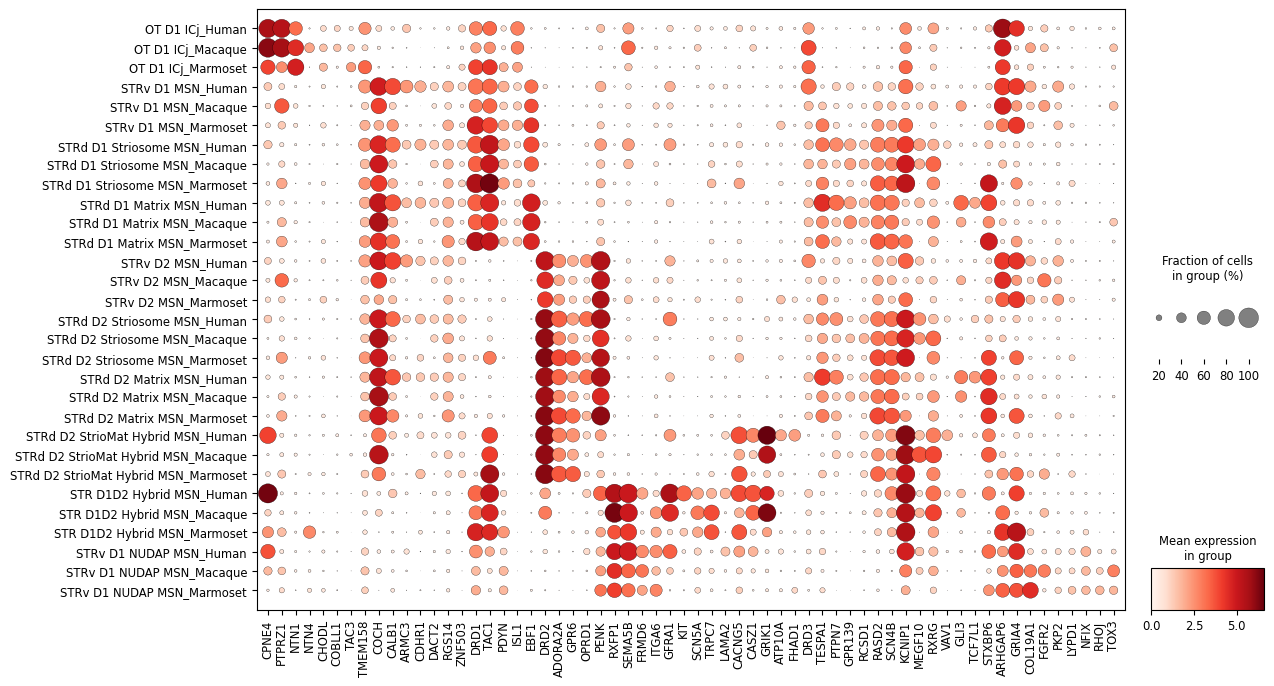

In [65]:
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_genes_curated_plus_known , 
    groupby=["Group", "organism"], 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    figsize=(13, 7.8),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

### gene list from the primate MSNs expr/tau analysis

In [4]:
df = pd.read_csv("/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/expressologs//MSN_vignette/group/group_expressologs_MSN_auroc_tau_metrics.csv")

#### 0.75 and 0.75

In [5]:
filtered_df = df[(df["xspecies_min"] > 0.75) & (df["auroc"] > 0.75)]
unique_genes = filtered_df["gene"].unique().tolist()

print(len(unique_genes))
print(unique_genes)

18
['CUX2', 'EBF1', 'ELAVL4', 'FRMD6', 'GRIK1', 'HTR7', 'KCNJ6', 'MOXD1', 'NFIB', 'NFIX', 'NTN1', 'RXFP1', 'SCN5A', 'SMYD2', 'TCF4', 'TRHDE', 'TRPC7', 'VWC2L']


In [7]:
expr_tau_tf = list(set(unique_genes) & set(tf_genes))
print(len(expr_tau_tf))
print(expr_tau_tf)

5
['EBF1', 'NFIB', 'NFIX', 'TCF4', 'CUX2']


In [15]:
unique_genes_ordered = ['CUX2', 'KCNJ6', 'NTN1', 'TCF4', 'EBF1', 'SMYD2', 'HTR7', 'ELAVL4', 'GRIK1', 'TRHDE', 'RXFP1','TRPC7', 'SCN5A',  'FRMD6', 'NFIB', 'NFIX', 'VWC2L']

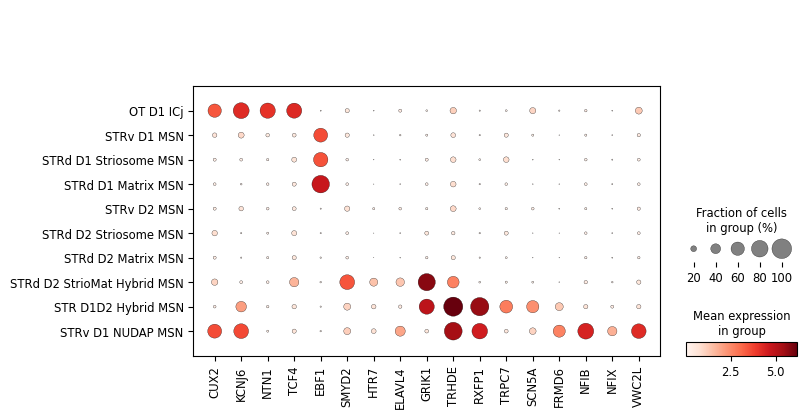

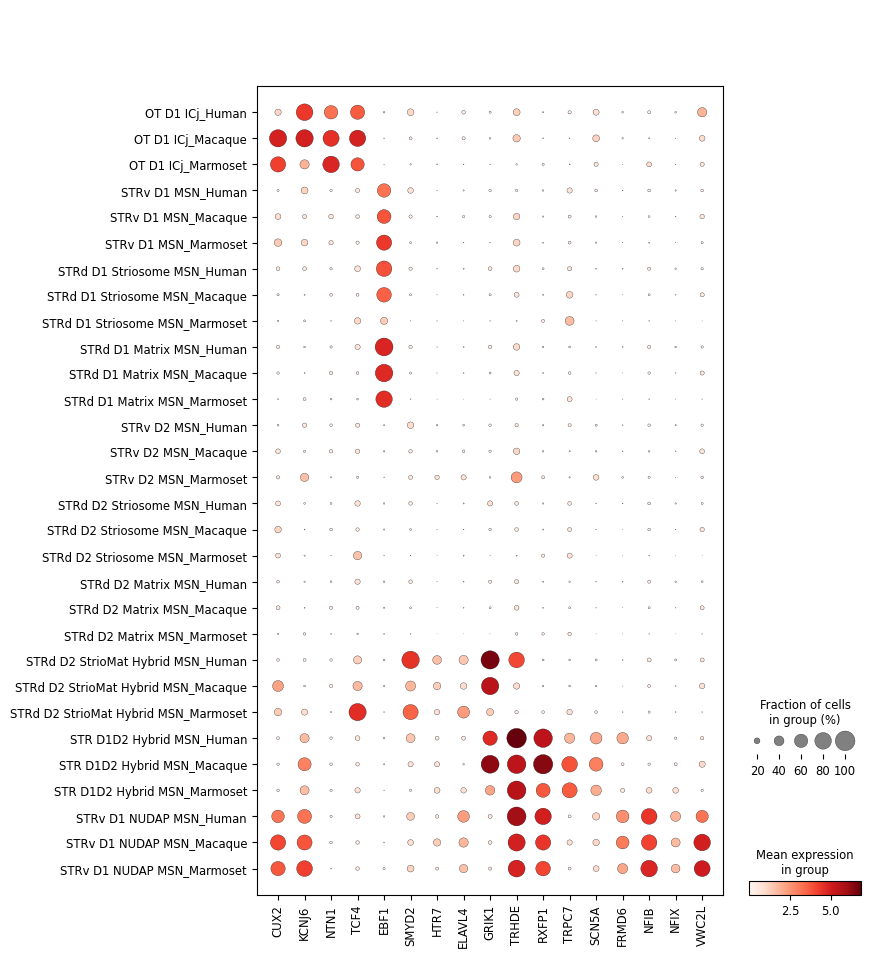

In [16]:
sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes_ordered, #unique_genes
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)
sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes_ordered, 
    groupby=["Group", "organism"], 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)


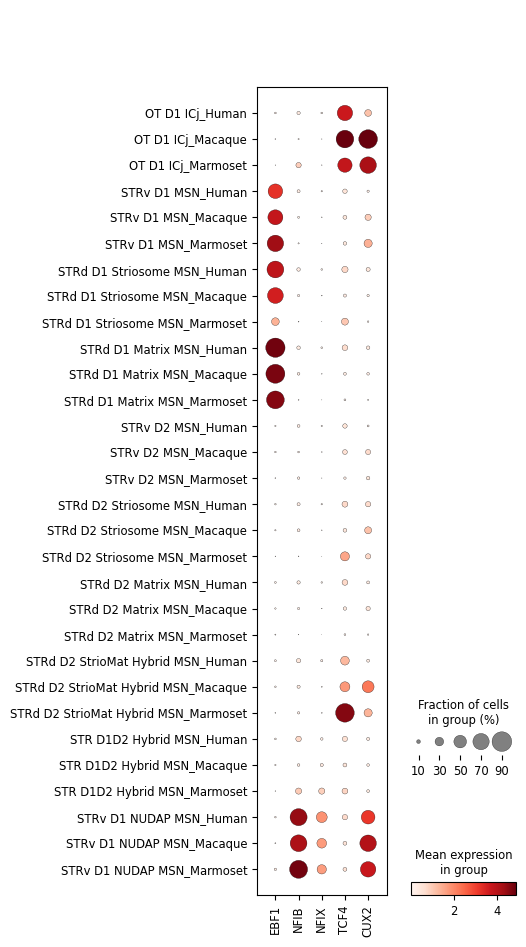

In [12]:
sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_tf, 
    groupby=["Group", "organism"], 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)

#### auroc 0.75, tau 0.6

In [17]:
filtered_df = df[(df["xspecies_min"] > 0.6) & (df["auroc"] > 0.75)]
unique_genes = filtered_df["gene"].unique().tolist()

print(len(unique_genes))
print(unique_genes)

85
['ADARB2', 'ADCY2', 'ADORA2A', 'ALK', 'AMOTL1', 'ANKFN1', 'ARHGAP18', 'ATP8B1', 'BTG1', 'CACNG5', 'CADPS2', 'CALCRL', 'CAMK2D', 'CCDC50', 'CHODL', 'CNTNAP4', 'CPNE4', 'CTBP2', 'CUX2', 'DRD2', 'EBF1', 'ELAVL2', 'ELAVL4', 'EPS8', 'EYA2', 'FRMD6', 'GABRA3', 'GABRG1', 'GFRA1', 'GNG2', 'GPR139', 'GPR6', 'GRIK1', 'GRIK3', 'HTR7', 'ILDR2', 'INSYN2B', 'ISL1', 'ITGA6', 'KCNH5', 'KCNJ3', 'KCNJ6', 'KIRREL1', 'LRFN2', 'LRIG1', 'MOXD1', 'NFIB', 'NFIX', 'NR4A3', 'NRP2', 'NTN1', 'OPRD1', 'PARP8', 'PDE1A', 'PLCB4', 'PPM1E', 'PTN', 'RASSF8', 'RXFP1', 'SCN5A', 'SEMA5B', 'SEZ6L', 'SHANK1', 'SHISA6', 'SIDT1', 'SMYD2', 'SNX7', 'SP9', 'STAC', 'TACR1', 'TAFA2', 'TCERG1L', 'TCF4', 'TIMP2', 'TMTC4', 'TNR', 'TRHDE', 'TRPC7', 'TSHZ1', 'UBE2QL1', 'VWC2L', 'WLS', 'ZBTB16', 'ZNF608', 'ZNF804B']


In [18]:
expr_tau_tf = list(set(unique_genes) & set(tf_genes))
print(len(expr_tau_tf))
print(expr_tau_tf)

12
['EBF1', 'ZBTB16', 'ISL1', 'SP9', 'NFIB', 'ZNF804B', 'NFIX', 'TSHZ1', 'NR4A3', 'TCF4', 'ZNF608', 'CUX2']


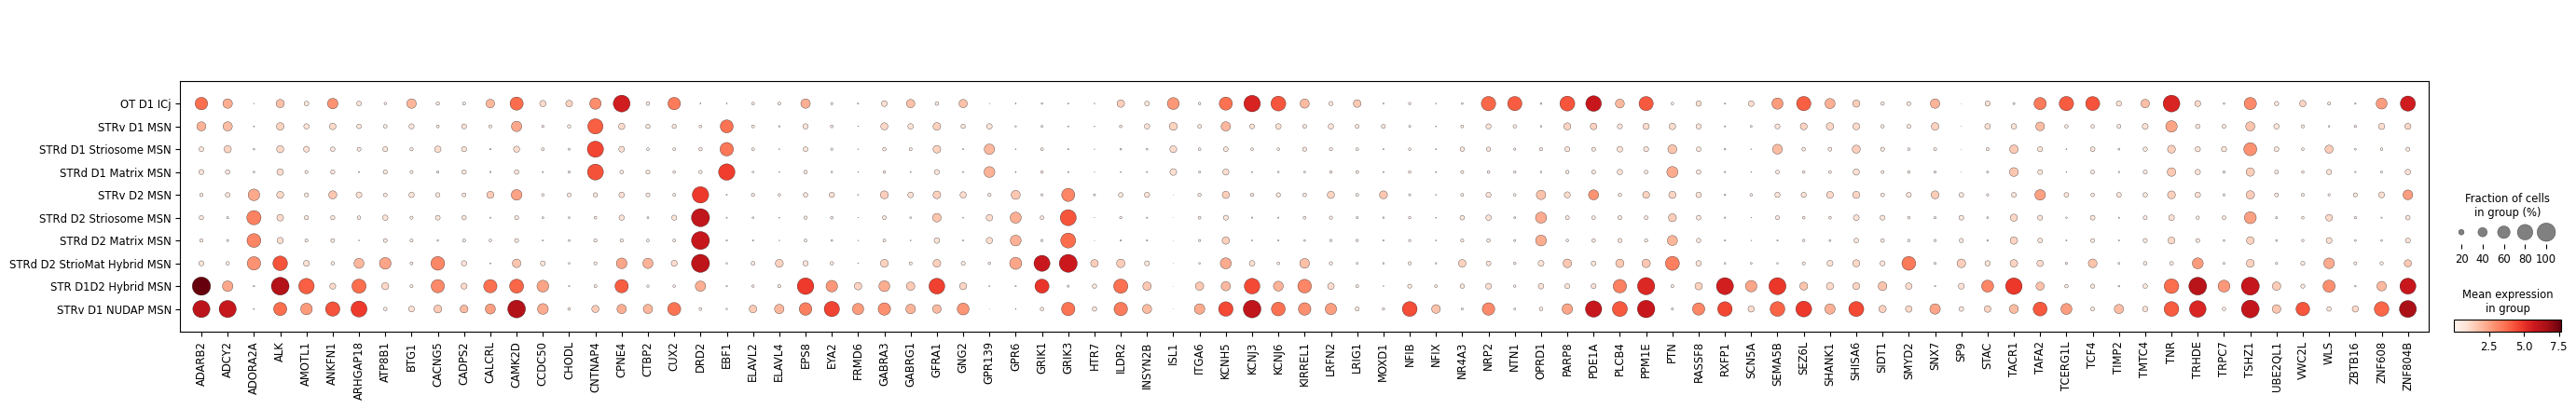

In [19]:
sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes, #unique_genes
    groupby="Group", 
    use_raw=False,
    dendrogram=False,
    standard_scale= 'None',#'var',#'None',  
    swap_axes=False,
    #figsize=(5.5, 2.5),
    #save="Dotplot_Astro_DopaReceptors.pdf"
)


In [21]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from anndata import AnnData

def order_genes_by_pattern(
    adata: AnnData,
    genes: list[str],
    group_key: str = "Group",
    layer: str | None = None,
    use_metric: str = "correlation",   # 'correlation' or 'euclidean'
    use_feature: str = "mean",         # 'mean' or 'fraction' or 'both'
) -> list[str]:
    """
    Returns genes reordered so that similar patterns across groups are adjacent.
    Row (group) order is kept as in adata.obs[group_key] categorical order.
    """
    # fix row order
    groups = adata.obs[group_key].astype("category")
    adata.obs[group_key] = groups
    group_order = list(groups.cat.categories)

    # choose matrix
    X = adata.layers[layer] if layer is not None else adata.X
    X = X.tocsr() if hasattr(X, "tocsr") else X

    # keep existing genes
    genes = [g for g in genes if g in adata.var_names]
    idx = adata.var_names.get_indexer(genes)

    # build group-by matrix (rows=groups, cols=genes)
    rows = []
    for g in group_order:
        mask = (adata.obs[group_key] == g).values
        sub = X[mask, :][:, idx]
        n = sub.shape[0]
        mean_vec = sub.sum(axis=0).A1 / max(n, 1)
        frac_vec = (sub > 0).sum(axis=0).A1 / max(n, 1)
        if use_feature == "mean":
            feat = mean_vec
        elif use_feature == "fraction":
            feat = frac_vec
        else:  # both: concatenate then z-score each block to balance scale
            a = (mean_vec - mean_vec.mean()) / (mean_vec.std() + 1e-9)
            b = (frac_vec - frac_vec.mean()) / (frac_vec.std() + 1e-9)
            feat = np.r_[a, b]
        rows.append(feat)

    M = np.vstack(rows)                # shape: (n_groups, n_genes) or (n_groups, 2*n_genes) for 'both'
    if use_feature == "both":
        # reshape back to gene × features
        nG = len(group_order)
        nV = len(genes)
        M = np.concatenate([M[:nG, :nV], M[:nG, nV:]], axis=0)  # not needed; correlation below works on cols

    # columns = genes; cluster columns by distance of their group-wise profiles
    D = pdist(M.T, metric=use_metric)  # distance between gene columns
    Z = linkage(D, method="average")   # or 'ward' if euclidean
    order = leaves_list(Z)
    return [genes[i] for i in order]


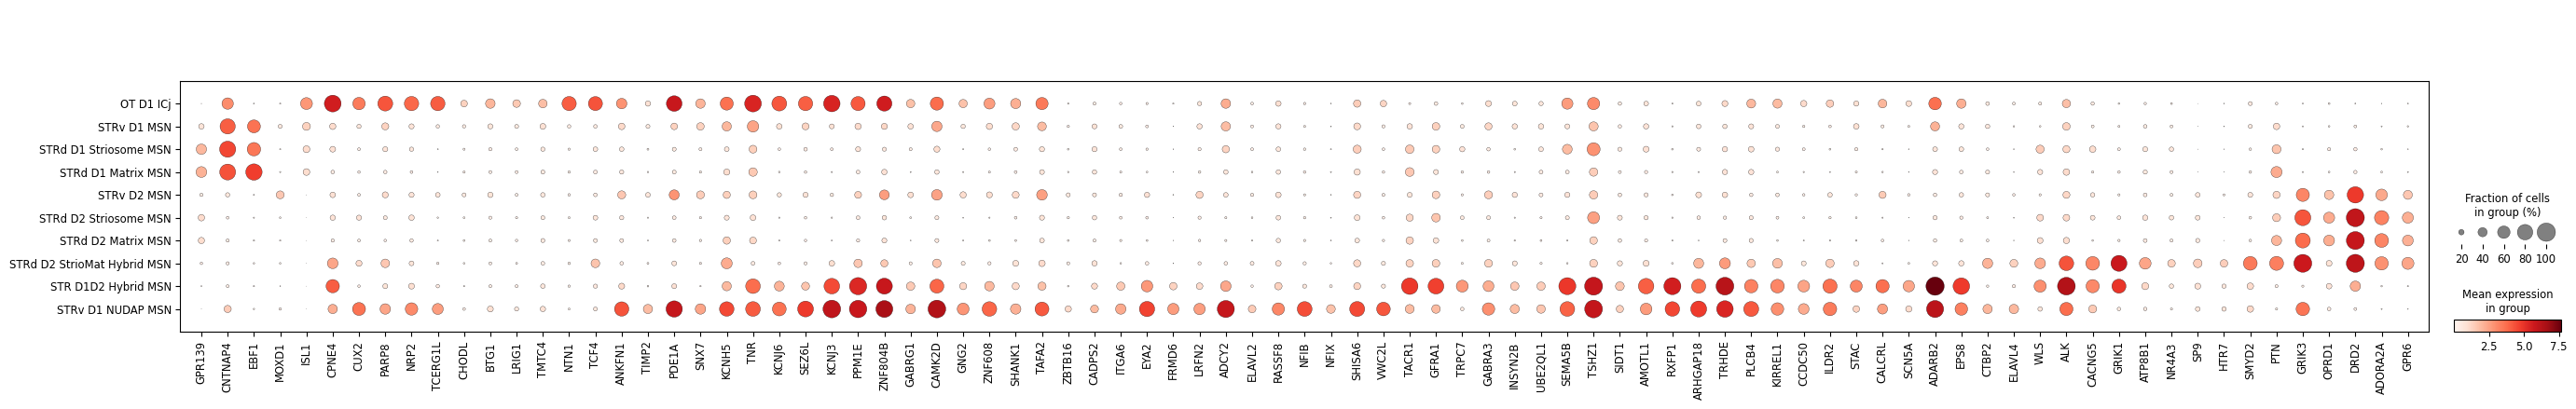

In [22]:
new_gene_order = order_genes_by_pattern(
    adata=adata_msn,
    genes=unique_genes,
    group_key="Group",
    layer=None,                
    use_metric="correlation",  
    use_feature="mean"         # 'mean'; 'fraction'; 'both'
)


sc.pl.dotplot(
    adata_msn,
    var_names=new_gene_order,
    groupby="Group",
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)


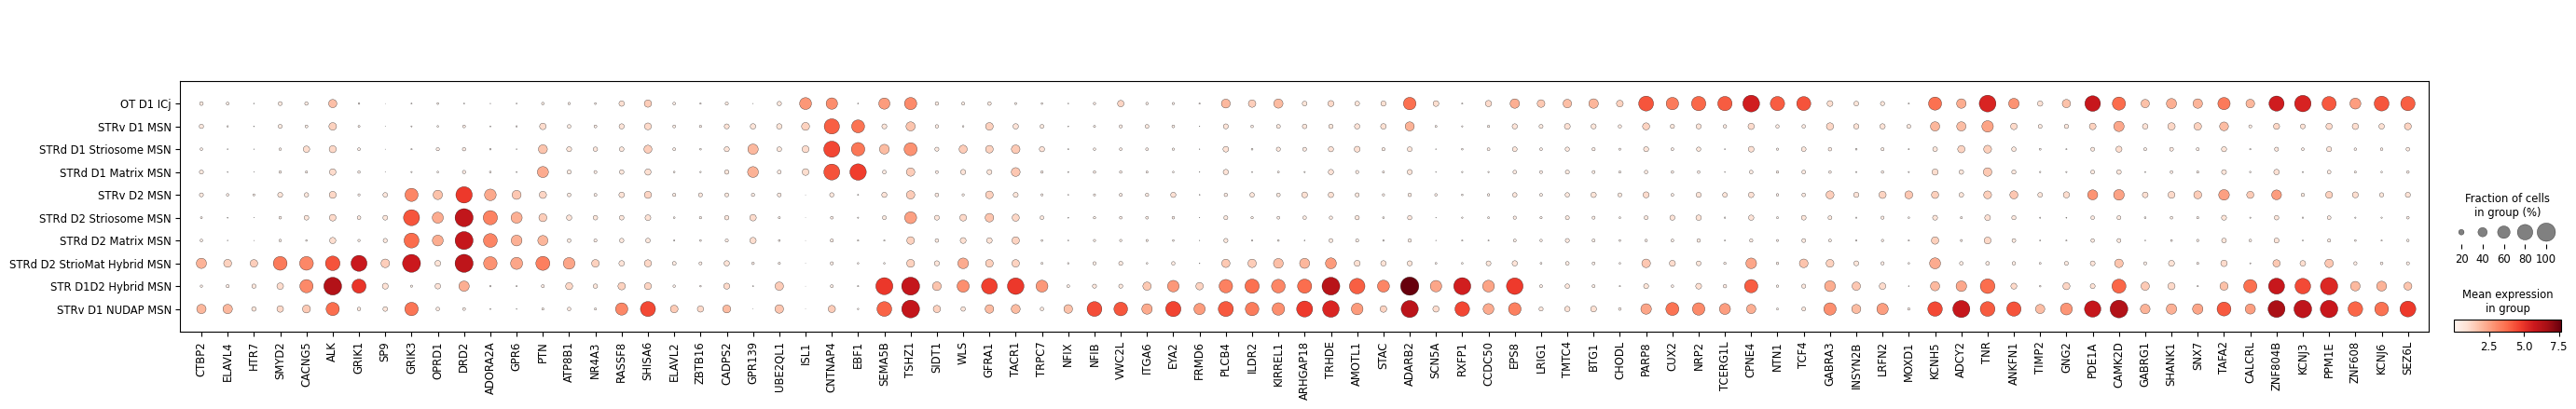

In [24]:
new_gene_order = order_genes_by_pattern(
    adata=adata_msn,
    genes=unique_genes,
    group_key="Group",
    layer=None,                
    use_metric="correlation",  
    use_feature="both"         # 'mean'; 'fraction'; 'both'
)


sc.pl.dotplot(
    adata_msn,
    var_names=new_gene_order,
    groupby="Group",
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)


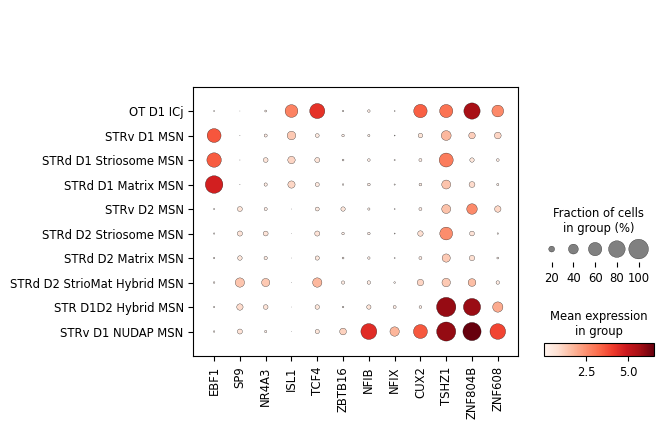

In [23]:
expr_tau_tf_order = order_genes_by_pattern(
    adata=adata_msn,
    genes=expr_tau_tf,
    group_key="Group",
    layer=None,                
    use_metric="correlation",  
    use_feature="mean"         
)


sc.pl.dotplot(
    adata_msn,
    var_names=expr_tau_tf_order,
    groupby="Group",
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)


#### human tau (type specific) high >0.75, and macaque/marmoset both <0.5 [only cell-type specific in human => potential human-specific markers?!)

In [25]:
filtered_df = df[(df["human"] > 0.75) & (df["macaque"] < 0.5) & (df["marmoset"] < 0.5)]
unique_genes = filtered_df["gene"].unique().tolist()

print(len(unique_genes))
print(unique_genes)

63
['ADAMTS5', 'AFAP1L2', 'AHRR', 'BLM', 'CA2', 'CAV1', 'CAV2', 'CBLN4', 'CCK', 'CDK15', 'CHRM2', 'COL27A1', 'CREG2', 'CRHR2', 'CXCL13', 'DAPL1', 'DNAH8', 'ENPEP', 'FGF2', 'FGFR1', 'FIGN', 'FREM2', 'GABRQ', 'GLRA1', 'GPR26', 'HMCN1', 'HS3ST1', 'ITGA1', 'KCTD4', 'KYNU', 'LECT2', 'LMNTD1', 'LURAP1L', 'MARCKSL1', 'MFGE8', 'MYO10', 'MYO1H', 'NKAIN1', 'NPFFR1', 'NXPH2', 'OTOGL', 'PDGFRA', 'PDLIM3', 'PHLDB2', 'PKDCC', 'PTGER3', 'RAB37', 'SAMD3', 'SHC2', 'SLC22A6', 'SLC5A8', 'SPINK5', 'SPTLC3', 'ST8SIA6', 'SYNPO2', 'TGFBR3', 'TLE2', 'TMC1', 'TMEM132C', 'TRPM4', 'VIP', 'VSTM5', 'ZNF385C']


In [26]:
expr_tau_tf = list(set(unique_genes) & set(tf_genes))
print(len(expr_tau_tf))
print(expr_tau_tf)

2
['AHRR', 'ZNF385C']


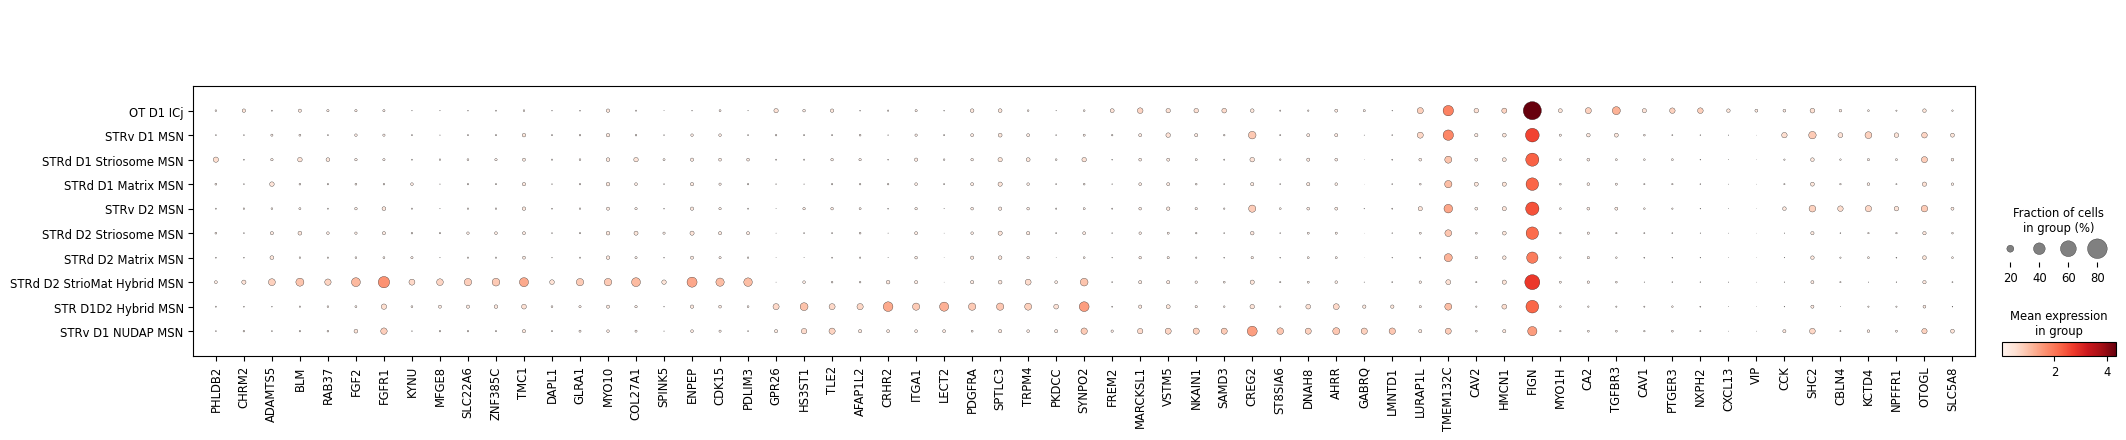

In [27]:
unique_genes_order = order_genes_by_pattern(
    adata=adata_msn,
    genes=unique_genes,
    group_key="Group",
    layer=None,                
    use_metric="correlation",  
    use_feature="mean"         
)


sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes_order,
    groupby="Group",
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)



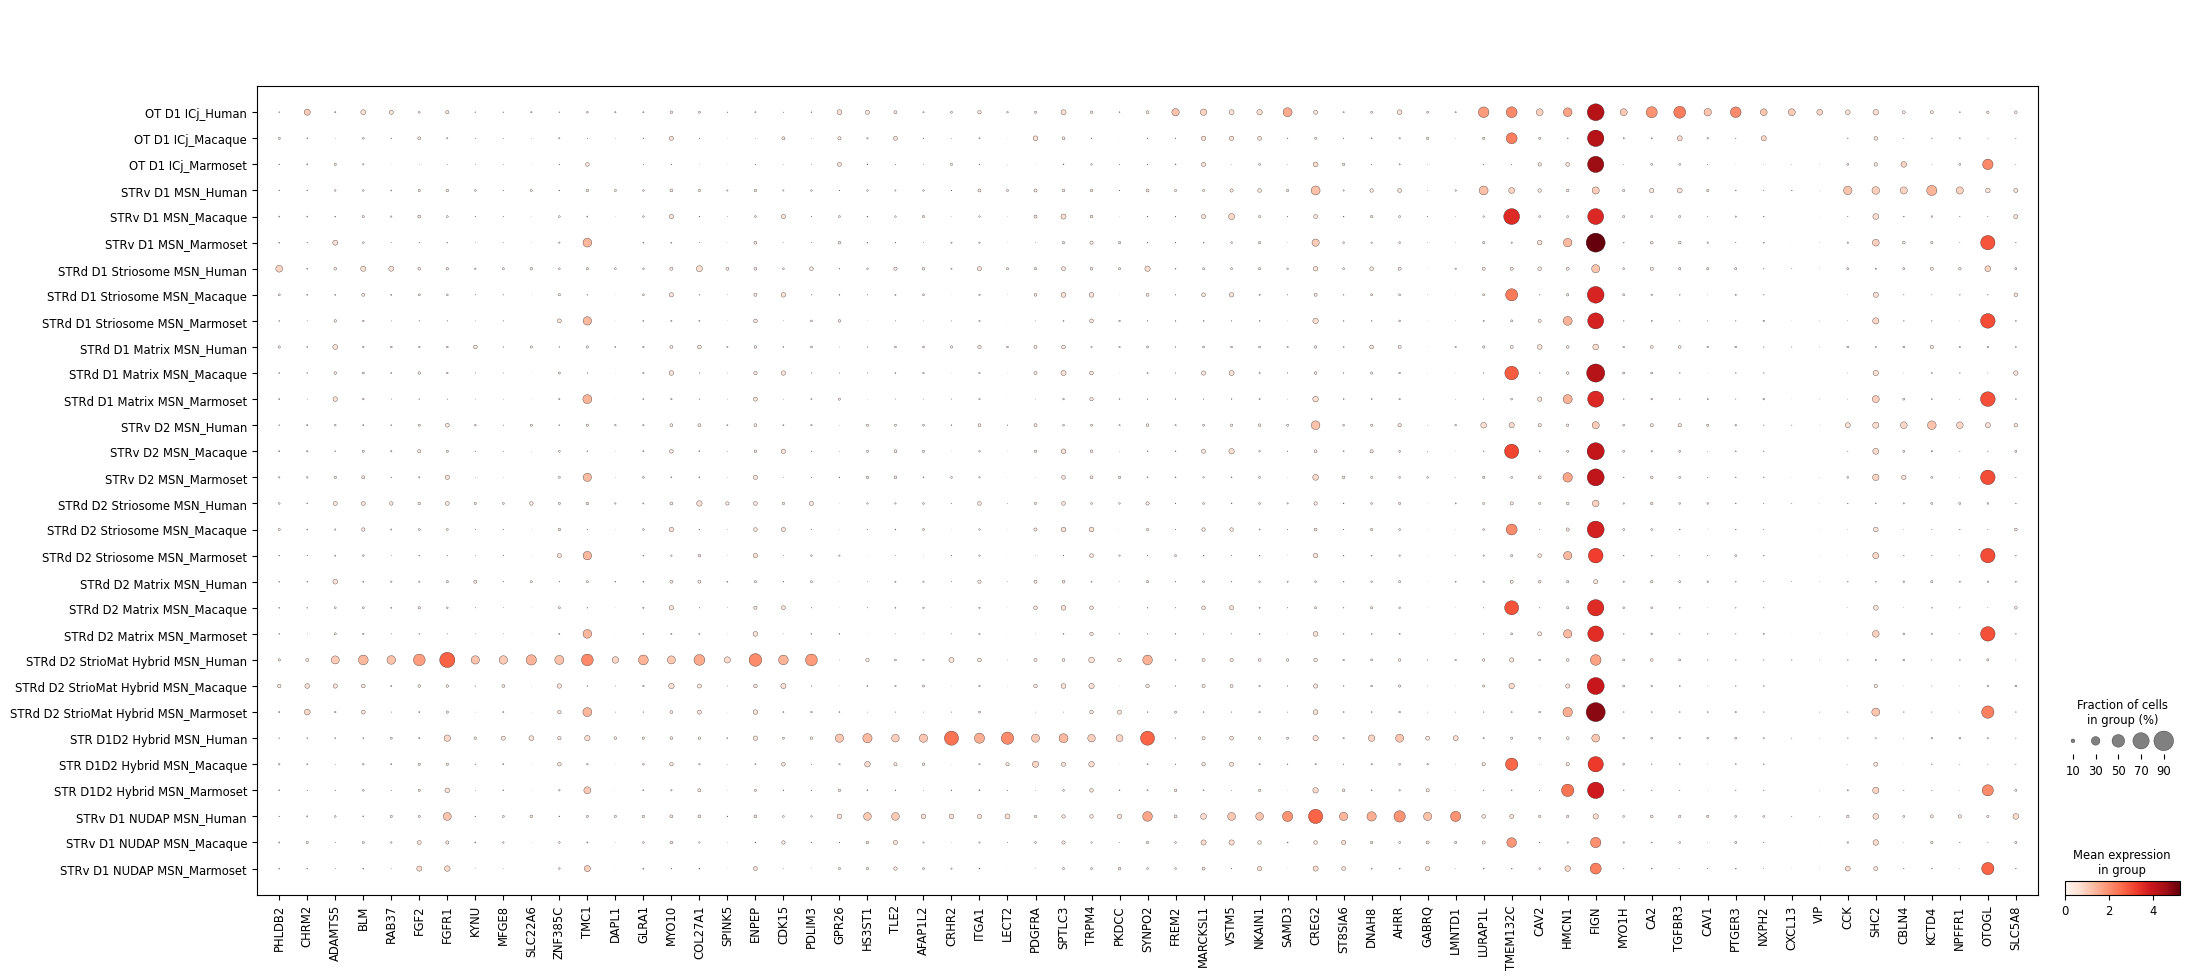

In [28]:
sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes_order,
    groupby=["Group", "organism"],
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)

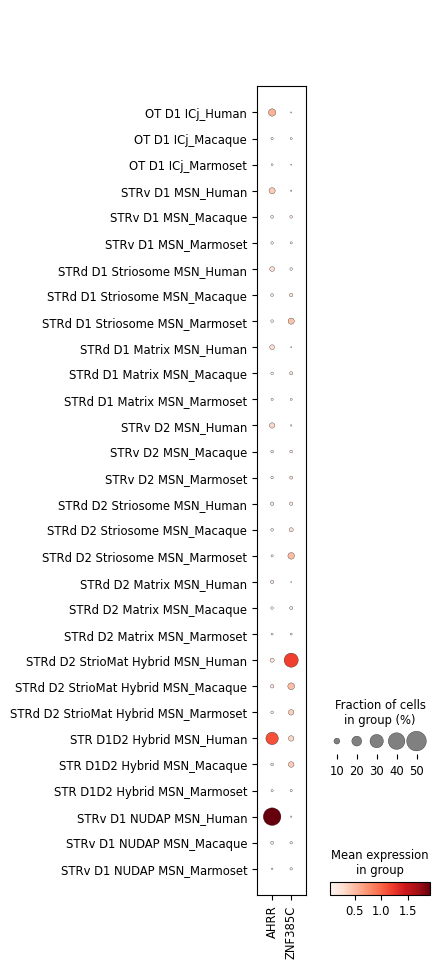

In [29]:
sc.pl.dotplot(
    adata_msn,
    var_names=['AHRR', 'ZNF385C'],
    groupby=["Group", "organism"],
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)

#### in contrast of - human tau (type specific) high >0.75, and macaque/marmoset both <0.5 [only cell-type specific in human => potential human-specific markers?!)

In [31]:
filtered_df = df[(df["human"] < 0.5) & (df["macaque"] > 0.75) & (df["marmoset"] > 0.75)]
unique_genes = filtered_df["gene"].unique().tolist()

print(len(unique_genes))
print(unique_genes)

expr_tau_tf = list(set(unique_genes) & set(tf_genes))
print(len(expr_tau_tf))
print(expr_tau_tf)

14
['ADCY8', 'ANKRD55', 'CHST9', 'FARP1', 'HTR2C', 'HUNK', 'IL20RA', 'NTN4', 'PEX5L', 'QRFPR', 'RHOJ', 'SCN7A', 'TAC3', 'TOX3']
0
[]


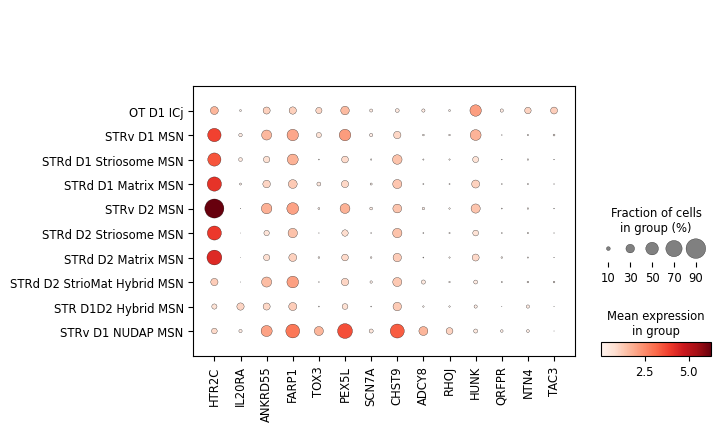

In [32]:
unique_genes_order = order_genes_by_pattern(
    adata=adata_msn,
    genes=unique_genes,
    group_key="Group",
    layer=None,                
    use_metric="correlation",  
    use_feature="mean"         
)


sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes_order,
    groupby="Group",
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)



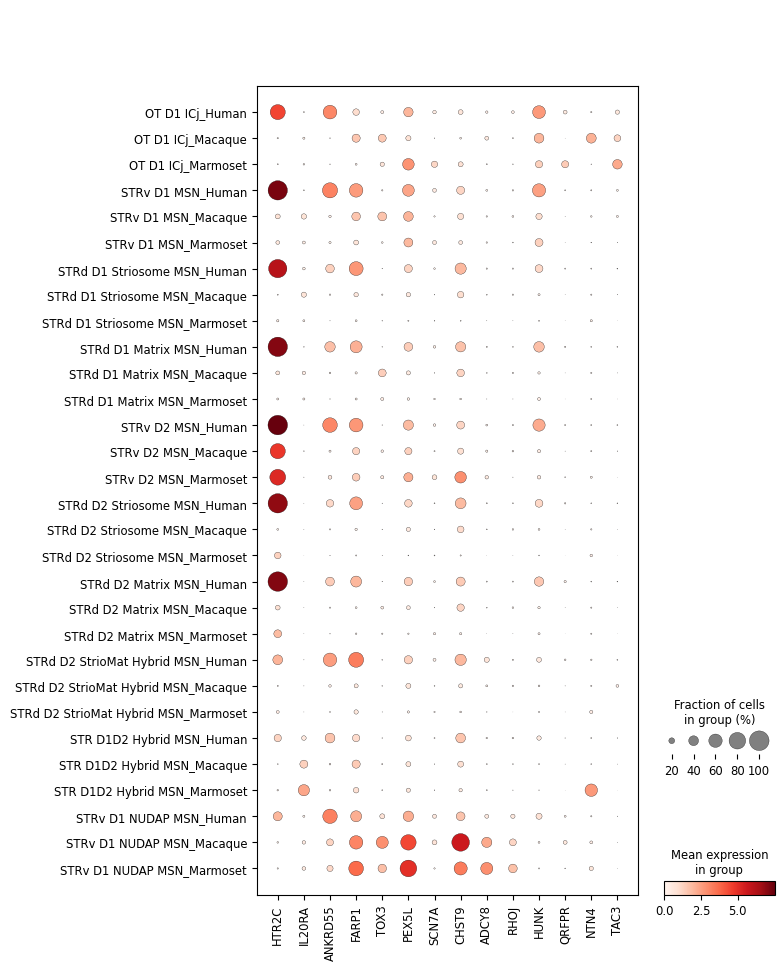

In [34]:
sc.pl.dotplot(
    adata_msn,
    var_names=unique_genes_order,
    groupby=["Group", "organism"],
    use_raw=False,
    dendrogram=False,   
    swap_axes=False,
    standard_scale=None
)

### gene list from the 4-species MSNs expr/tau analysis

### abundance

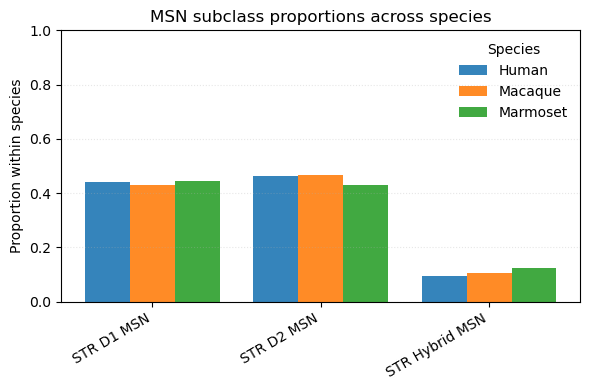

In [18]:
import matplotlib.pyplot as plt

selected = ["STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN"]
obs = adata_msn.obs[adata_msn.obs["Subclass"].isin(selected)].copy()

counts_wide = pd.crosstab(obs["Subclass"], obs["organism"])

wide = counts_wide.div(counts_wide.sum(axis=0), axis=1)

subclass_order = ["STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN"]
species_order  = [sp for sp in ["Human", "Macaque", "Marmoset"] if sp in wide.columns]
wide = wide.reindex(index=subclass_order, columns=species_order).fillna(0.0)


fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(wide.index))
nsp = len(wide.columns)
bar_w = 0.8 / max(nsp, 1)

for i, sp in enumerate(wide.columns):
    ax.bar(x + (i - (nsp-1)/2)*bar_w, wide[sp].values,
           width=bar_w, label=sp, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(wide.index, rotation=30, ha="right")
ax.set_ylabel("Proportion within species")
ax.set_ylim(0, 1)
ax.set_title("MSN subclass proportions across species")
ax.legend(title="Species", frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()


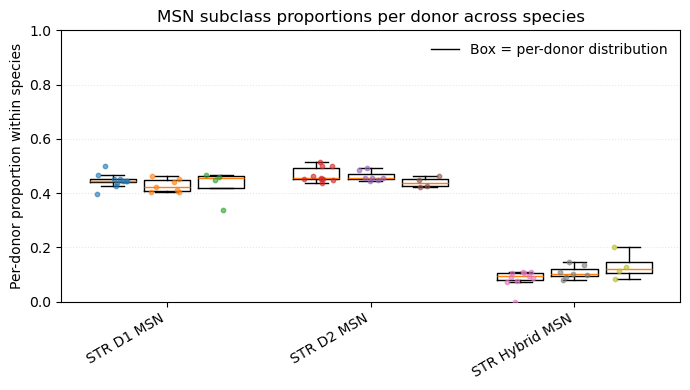

In [24]:
# --- subset to the three MSN subclasses ---
selected = ["STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN"]
obs = adata_msn.obs[adata_msn.obs["Subclass"].isin(selected)].copy()

# --- per-donor totals (MSN cells) within species ---
totals = (obs.groupby(["organism","donor_id"])
            .size()
            .rename("total_msn_per_donor"))

# --- per-donor subclass counts ---
counts = (obs.groupby(["organism","donor_id","Subclass"])
            .size()
            .rename("n_cells"))

# merge and compute per-donor proportion of each subclass
df = (counts.reset_index()
            .merge(totals.reset_index(), on=["organism","donor_id"], how="left"))
df["proportion"] = df["n_cells"] / df["total_msn_per_donor"]

# desired orders
subclass_order = ["STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN"]
species_order  = [sp for sp in ["Human","Macaque","Marmoset"] if sp in df["organism"].unique()]

# --- collect data lists for boxplot (one list per Subclass×Species) ---
data_lists = []
labels_pos  = []
x = np.arange(len(subclass_order))      # 3 groups
nsp = len(species_order)
group_w = 0.8
dx = group_w / max(nsp,1)

positions = []
for i, sc in enumerate(subclass_order):
    for j, sp in enumerate(species_order):
        vals = df.loc[(df["Subclass"]==sc) & (df["organism"]==sp), "proportion"].dropna().values
        data_lists.append(vals)
        # x-position for this box
        pos = x[i] + (j - (nsp-1)/2)*dx
        positions.append(pos)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 4))

# boxplot (showfliers可开/关；whis=IQR*1.5)
bp = ax.boxplot(
    data_lists,
    positions=positions,
    widths=dx*0.85,
    manage_ticks=False,
    showfliers=False
)


rng = np.random.default_rng(0)
for vals, pos in zip(data_lists, positions):
    if len(vals):
        jitter = (rng.random(len(vals)) - 0.5) * dx*0.6
        ax.scatter(np.full_like(vals, pos)+jitter, vals, s=10, alpha=0.6, zorder=3)


ax.set_xticks(x)
ax.set_xticklabels(subclass_order, rotation=30, ha="right")

ax.set_ylabel("Per-donor proportion within species")
ax.set_ylim(0, 1)
ax.set_title("MSN subclass proportions per donor across species")
ax.grid(axis="y", linestyle=":", alpha=0.3)


from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color="black", lw=1)]
legend_labels  = ["Box = per-donor distribution"]
ax.legend(legend_handles, legend_labels, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


In [21]:
set(adata_msn.obs['Group'])

{'STR D1D2 Hybrid MSN',
 'STRd D1 Matrix MSN',
 'STRd D1 Striosome MSN',
 'STRd D2 Matrix MSN',
 'STRd D2 StrioMat Hybrid MSN',
 'STRd D2 Striosome MSN',
 'STRv D1 MSN',
 'STRv D1 NUDAP MSN',
 'STRv D2 MSN'}

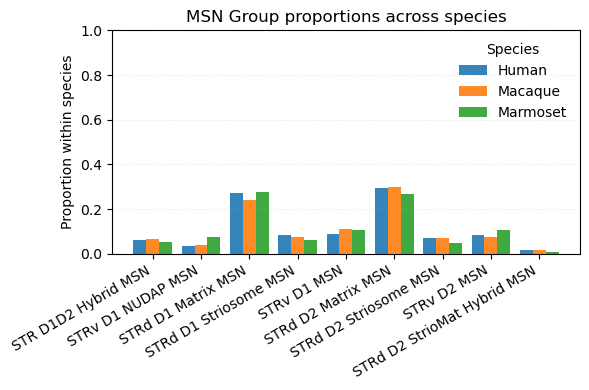

In [22]:
selected = ["STR D1D2 Hybrid MSN", "STRv D1 NUDAP MSN",'STRd D1 Matrix MSN','STRd D1 Striosome MSN','STRv D1 MSN', 'STRd D2 Matrix MSN','STRd D2 Striosome MSN','STRv D2 MSN','STRd D2 StrioMat Hybrid MSN',]
obs = adata_msn.obs[adata_msn.obs["Group"].isin(selected)].copy()

counts_wide = pd.crosstab(obs["Group"], obs["organism"])

wide = counts_wide.div(counts_wide.sum(axis=0), axis=1)

subclass_order = ["STR D1D2 Hybrid MSN", "STRv D1 NUDAP MSN",'STRd D1 Matrix MSN','STRd D1 Striosome MSN','STRv D1 MSN', 'STRd D2 Matrix MSN','STRd D2 Striosome MSN','STRv D2 MSN','STRd D2 StrioMat Hybrid MSN',]
species_order  = [sp for sp in ["Human", "Macaque", "Marmoset"] if sp in wide.columns]
wide = wide.reindex(index=subclass_order, columns=species_order).fillna(0.0)


fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(wide.index))
nsp = len(wide.columns)
bar_w = 0.8 / max(nsp, 1)

for i, sp in enumerate(wide.columns):
    ax.bar(x + (i - (nsp-1)/2)*bar_w, wide[sp].values,
           width=bar_w, label=sp, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(wide.index, rotation=30, ha="right")
ax.set_ylabel("Proportion within species")
ax.set_ylim(0, 1)
ax.set_title("MSN Group proportions across species")
ax.legend(title="Species", frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

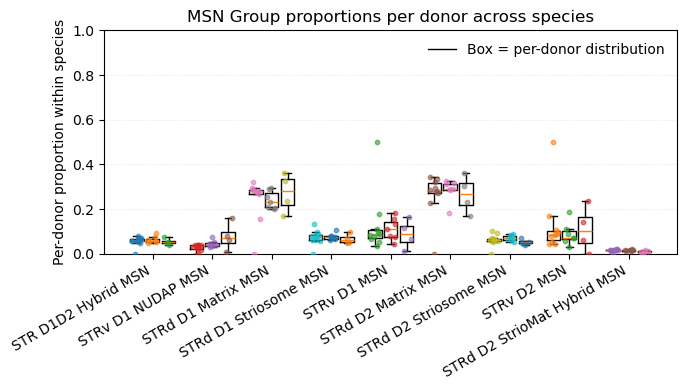

In [23]:
# --- per-donor totals (MSN cells) within species ---
totals = (obs.groupby(["organism","donor_id"])
            .size()
            .rename("total_msn_per_donor"))

# --- per-donor subclass counts ---
counts = (obs.groupby(["organism","donor_id","Group"])
            .size()
            .rename("n_cells"))

# merge and compute per-donor proportion of each subclass
df = (counts.reset_index()
            .merge(totals.reset_index(), on=["organism","donor_id"], how="left"))
df["proportion"] = df["n_cells"] / df["total_msn_per_donor"]


# --- collect data lists for boxplot (one list per Subclass×Species) ---
data_lists = []
labels_pos  = []
x = np.arange(len(subclass_order))      # 3 groups
nsp = len(species_order)
group_w = 0.8
dx = group_w / max(nsp,1)

positions = []
for i, sc in enumerate(subclass_order):
    for j, sp in enumerate(species_order):
        vals = df.loc[(df["Group"]==sc) & (df["organism"]==sp), "proportion"].dropna().values
        data_lists.append(vals)
        # x-position for this box
        pos = x[i] + (j - (nsp-1)/2)*dx
        positions.append(pos)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 4))

# boxplot (showfliers可开/关；whis=IQR*1.5)
bp = ax.boxplot(
    data_lists,
    positions=positions,
    widths=dx*0.85,
    manage_ticks=False,
    showfliers=False
)


rng = np.random.default_rng(0)
for vals, pos in zip(data_lists, positions):
    if len(vals):
        jitter = (rng.random(len(vals)) - 0.5) * dx*0.6
        ax.scatter(np.full_like(vals, pos)+jitter, vals, s=10, alpha=0.6, zorder=3)


ax.set_xticks(x)
ax.set_xticklabels(subclass_order, rotation=30, ha="right")

ax.set_ylabel("Per-donor proportion within species")
ax.set_ylim(0, 1)
ax.set_title("MSN Group proportions per donor across species")
ax.grid(axis="y", linestyle=":", alpha=0.3)


from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color="black", lw=1)]
legend_labels  = ["Box = per-donor distribution"]
ax.legend(legend_handles, legend_labels, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

In [12]:
from typing import Optional, List
from anndata import AnnData
import numpy as np
import pandas as pd

def downsample_per_cluster_donor(
    adata: AnnData,
    cluster_key: str = "Cluster",
    donor_key: str = "donor_id",
    max_cells_per_group: int = 50,
    clusters_to_include: Optional[List[str]] = None,
    require_shared_donors: bool = True,
    random_state: Optional[int] = None
) -> AnnData:
    """
    Downsample per (cluster × donor) to a maximum number of cells,
    with optional filtering to retain only donors shared across multiple clusters.
    Supports fixed random seed for reproducibility.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object.
    cluster_key : str
        Column in .obs specifying clusters.
    donor_key : str
        Column in .obs specifying donor IDs.
    max_cells_per_group : int
        Maximum number of cells per (cluster × donor) group.
    clusters_to_include : list of str, optional
        Only retain these clusters if provided.
    require_shared_donors : bool
        If True, only keep donors that appear in ≥2 of the specified clusters.
    random_state : int, optional
        Seed for reproducible downsampling. If None, randomness is not fixed.

    Returns
    -------
    AnnData
        Downsampled AnnData object.
    """
    obs = adata.obs
    if clusters_to_include is not None:
        obs = obs[obs[cluster_key].isin(clusters_to_include)]

    # Identify donors present in ≥2 different clusters
    if require_shared_donors:
        donor_cluster_counts = obs.groupby(donor_key)[cluster_key].nunique()
        shared_donors = donor_cluster_counts[donor_cluster_counts >= 2].index.tolist()
        obs = obs[obs[donor_key].isin(shared_donors)]

    rng = np.random.default_rng(random_state)  # reproducible generator
    selected_indices = []

    for clus in obs[cluster_key].unique():
        clus_df = obs[obs[cluster_key] == clus]
        for donor in clus_df[donor_key].unique():
            donor_cells = clus_df[clus_df[donor_key] == donor].index.tolist()
            if len(donor_cells) <= max_cells_per_group:
                selected_indices.extend(donor_cells)
            else:
                sampled = rng.choice(donor_cells, size=max_cells_per_group, replace=False)
                selected_indices.extend(sampled)

    return adata[selected_indices].copy()


## DEGs between classic D1/D2 islands and Hybrid island per species 

In [3]:
adata_msn = sc.read_h5ad("Consensus_preprint_3species_MSNs_withlogCPM_X.h5ad")

In [4]:
mapping = {
    "STR Hybrid MSN": "Hybrid",
    "STR D1 MSN": "Classic",
    "STR D2 MSN": "Classic",
}

adata_msn.obs["hybrid_vs_classic"] = adata_msn.obs["Subclass"].map(mapping)
#ordered
adata_msn.obs["hybrid_vs_classic"] = pd.Categorical(
    adata_msn.obs["hybrid_vs_classic"],
    categories=["Hybrid", "Classic"],  
    ordered=False,
)

adata_msn.obs["hybrid_vs_classic"].value_counts(dropna=False)


hybrid_vs_classic
Classic    754554
Hybrid      86451
Name: count, dtype: int64

In [5]:
adata_msn_human = adata_msn[adata_msn.obs["organism"].isin(['Human'])].copy()
adata_msn_macaque = adata_msn[adata_msn.obs["organism"].isin(['Macaque'])].copy()
adata_msn_marmoset = adata_msn[adata_msn.obs["organism"].isin(['Marmoset'])].copy()

In [6]:
from scipy.stats import spearmanr
from typing import Dict, Optional, List, Tuple
from anndata import AnnData
import scipy.sparse as sp
import matplotlib.pyplot as plt


def _to_dense(X):
    """Safely convert a (possibly sparse) matrix to dense numpy array."""
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)


def compute_group_medians_by_species(
    adata: AnnData,
    species_key: str = "organism",
    group_key: str = "Group",
    use_raw: bool = False,
    genes_filter: Optional[List[str]] = None,
    min_cells_per_group: int = 1
) -> Dict[str, pd.DataFrame]:
    """
    Compute per-species, per-group median expression across genes.

    Returns a dict mapping species -> DataFrame of shape (n_groups, n_genes),
    where each row is a group's median gene expression vector within that species.

    Parameters
    ----------
    adata : AnnData
        Integrated AnnData containing multiple species.
    species_key : str
        Column in .obs that specifies species (e.g., 'organism').
    group_key : str
        Column in .obs that specifies groups/clusters within each species (e.g., 'Group').
    use_raw : bool
        If True, use adata.raw.X and adata.raw.var_names.
    genes_filter : list of str or None
        Optional list of gene names to subset columns (must be present in var_names).
    min_cells_per_group : int
        Minimum number of cells required to compute a median for the group. Groups
        with fewer cells are dropped.

    Returns
    -------
    medians_by_species : Dict[str, pd.DataFrame]
        Keys are species values; values are DataFrames indexed by group IDs with columns = genes.
    """
    # Select expression matrix and gene names
    expr = adata.raw.X if use_raw else adata.X
    var_names = np.array(adata.raw.var_names if use_raw else adata.var_names, dtype=str)

    # Optional gene filtering with order preserved
    if genes_filter is not None:
        genes_filter = [g for g in genes_filter if g in set(var_names)]
        if len(genes_filter) == 0:
            raise ValueError("None of the genes in genes_filter are present in var_names.")
        gene_mask = np.isin(var_names, genes_filter)
        var_names = var_names[gene_mask]
        expr = expr[:, gene_mask]

    # Ensure consistent dtypes for keys
    species_series = adata.obs[species_key].astype(str)
    group_series = adata.obs[group_key].astype(str)

    medians_by_species: Dict[str, pd.DataFrame] = {}

    # Iterate over species
    for spc in sorted(species_series.unique()):
        spc_mask = (species_series == spc).values
        if spc_mask.sum() == 0:
            continue

        # Slice AnnData-like arrays efficiently
        X_spc = expr[spc_mask, :]
        groups_spc = group_series[spc_mask].values

        # Compute median per group
        group_ids = sorted(pd.unique(groups_spc))
        rows = []
        row_names = []

        X_spc_dense = None  # lazily materialize dense per group to save memory when possible

        for gid in group_ids:
            gmask = (groups_spc == gid)
            n_cells = int(gmask.sum())
            if n_cells < min_cells_per_group:
                continue

            # Subset rows for this group
            Xg = X_spc[gmask, :]

            # Convert to dense once per group if needed
            Xg = _to_dense(Xg)

            # Median across cells, per gene
            med = np.median(Xg, axis=0)
            rows.append(med)
            row_names.append(gid)

        if len(rows) == 0:
            # No valid groups for this species
            continue

        df = pd.DataFrame(np.vstack(rows), index=row_names, columns=var_names).astype(float)
        medians_by_species[spc] = df

    return medians_by_species


def spearman_within_species(
    medians_by_species: Dict[str, pd.DataFrame]
) -> Dict[str, pd.DataFrame]:
    """
    For each species, compute a group×group Spearman correlation matrix across genes.

    Parameters
    ----------
    medians_by_species : Dict[str, pd.DataFrame]
        Output from compute_group_medians_by_species(), mapping species -> (groups × genes).

    Returns
    -------
    corr_by_species : Dict[str, pd.DataFrame]
        Mapping species -> DataFrame (groups × groups) of Spearman correlations.
    """
    corr_by_species: Dict[str, pd.DataFrame] = {}

    for spc, df in medians_by_species.items():
        # df: rows=groups, cols=genes
        if df.shape[0] < 2:
            # Need at least two groups to compute correlations
            continue

        # Spearman across genes: correlation between group profiles
        # spearmanr expects observations in rows when axis=1 compares rows.
        corr = spearmanr(df.values, axis=1).correlation  # (n_groups + n_groups) if paired, but here it's square
        # For a single input (m×n), spearmanr returns an m×m correlation between rows.
        # However, older SciPy versions can behave differently; to be safe, slice square.
        n = df.shape[0]
        corr_mat = corr[:n, :n]

        corr_df = pd.DataFrame(corr_mat, index=df.index, columns=df.index)
        corr_by_species[spc] = corr_df

    return corr_by_species


def plot_correlation_heatmap_matplotlib(
    corr_df: pd.DataFrame,
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (8, 7),
    vmin: float = -1.0,
    vmax: float = 1.0,
    cmap: str = "viridis",
    annotate: bool = False,
    annotation_fmt: str = ".2f",
    output_file: Optional[str] = None,
):
    """
    Plot a group×group correlation heatmap using pure matplotlib (no seaborn).

    Parameters
    ----------
    corr_df : pd.DataFrame
        Square correlation matrix (groups × groups).
    title : str, optional
        Figure title.
    figsize : tuple
        Matplotlib figure size.
    vmin, vmax : float
        Color scale limits.
    cmap : str
        Matplotlib colormap name.
    annotate : bool
        If True, draw correlation values in each cell.
    annotation_fmt : str
        Format string for annotations (e.g., '.2f').
    output_file : str or None
        If provided, save the figure to this path.
    """
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr_df.values, vmin=vmin, vmax=vmax, cmap=cmap, aspect='equal')

    # Ticks and labels
    ax.set_xticks(np.arange(corr_df.shape[1]))
    ax.set_yticks(np.arange(corr_df.shape[0]))
    ax.set_xticklabels(corr_df.columns, rotation=90)
    ax.set_yticklabels(corr_df.index)

    # Grid lines
    ax.set_xticks(np.arange(-.5, corr_df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, corr_df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Spearman correlation", rotation=90)

    if title:
        ax.set_title(title)

    # Optional annotations
    if annotate:
        m, n = corr_df.shape
        for i in range(m):
            for j in range(n):
                ax.text(j, i, format(corr_df.iat[i, j], annotation_fmt),
                        ha="center", va="center", fontsize=8)

    fig.tight_layout()
    if output_file:
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

In [18]:
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy as sch
import matplotlib.pyplot as plt
from matplotlib import gridspec

def reorder_by_linkage_from_corr(
    corr_df: pd.DataFrame,
    method: str = "average",
    optimal_ordering: bool = True
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """
    Reorder a square correlation matrix using hierarchical clustering.

    Parameters
    ----------
    corr_df : pd.DataFrame
        Square correlation matrix (groups × groups).
    method : str
        Linkage method for scipy.cluster.hierarchy.linkage (e.g., 'average', 'complete', 'ward').
        Note: 'ward' requires Euclidean distances; for correlations, 'average' or 'complete' are common.
    optimal_ordering : bool
        If True, uses optimal leaf ordering to match original distances.

    Returns
    -------
    corr_reordered : pd.DataFrame
        Reordered correlation matrix.
    Z : np.ndarray
        Linkage matrix returned by scipy.
    leaves : np.ndarray
        Leaf order (indices into the original row/column order).
    """
    # Convert correlation to a distance in [0, 2]; force diagonal to 0
    corr = corr_df.values.astype(float)
    np.fill_diagonal(corr, 1.0)
    dist = 1.0 - corr
    np.fill_diagonal(dist, 0.0)

    # Condensed distance vector for linkage
    dist_condensed = squareform(dist, checks=False)

    # Linkage on distances
    Z = sch.linkage(dist_condensed, method=method, optimal_ordering=optimal_ordering)

    # Leaves order
    leaves = sch.leaves_list(Z)

    # Reorder rows/cols
    labels = corr_df.index.to_numpy()
    corr_reordered = corr_df.iloc[leaves, :].iloc[:, leaves]
    corr_reordered.index = labels[leaves]
    corr_reordered.columns = labels[leaves]

    return corr_reordered, Z, leaves


def plot_correlation_heatmap_with_dendrogram(
    corr_df: pd.DataFrame,
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (9, 9),
    vmin: float = -1.0,
    vmax: float = 1.0,
    cmap: str = "viridis",
    annotate: bool = False,
    annotation_fmt: str = ".2f",
    linkage_method: str = "average",
    optimal_ordering: bool = True,
    output_file: Optional[str] = None,
):
    """
    Plot a correlation heatmap with top and left dendrograms (pure matplotlib).

    Parameters
    ----------
    corr_df : pd.DataFrame
        Square correlation matrix (groups × groups).
    title : str, optional
        Figure title.
    figsize : tuple
        Overall figure size.
    vmin, vmax : float
        Color scale limits for the heatmap.
    cmap : str
        Matplotlib colormap name.
    annotate : bool
        If True, draw correlation values in each cell.
    annotation_fmt : str
        Format for annotations (e.g., '.2f').
    linkage_method : str
        Linkage method for hierarchical clustering (e.g., 'average', 'complete').
    optimal_ordering : bool
        Use optimal leaf ordering when forming dendrograms.
    output_file : str or None
        If provided, save the figure to this path.

    Returns
    -------
    corr_reordered : pd.DataFrame
        Reordered correlation matrix (matching dendrogram leaves).
    """
    # Reorder by hierarchical clustering
    corr_reordered, Z, leaves = reorder_by_linkage_from_corr(
        corr_df, method=linkage_method, optimal_ordering=optimal_ordering
    )

    # Layout: 2x2 grid (top dendrogram, left dendrogram, heatmap, and colorbar on the right)
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        2, 2,
        width_ratios=[0.2, 0.8],
        height_ratios=[0.2, 0.8],
        wspace=0.05,
        hspace=0.05
    )

    # Axes
    ax_dendro_col = fig.add_subplot(gs[0, 1])
    ax_dendro_row = fig.add_subplot(gs[1, 0])
    ax_matrix     = fig.add_subplot(gs[1, 1])
    # Colorbar axis (create a small inset on the right)
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    ax_cbar = inset_axes(ax_matrix, width="3%", height="60%", loc="right", borderpad=1.5)

    # Column dendrogram (top)
    sch.dendrogram(
        Z,
        ax=ax_dendro_col,
        no_labels=True,
        color_threshold=None
    )
    ax_dendro_col.set_xticks([])
    ax_dendro_col.set_yticks([])
    ax_dendro_col.set_xlim([0, len(leaves)])

    # Row dendrogram (left): use the same linkage but plot sideways
    sch.dendrogram(
        Z,
        ax=ax_dendro_row,
        orientation="right",
        no_labels=True,
        color_threshold=None
    )
    ax_dendro_row.set_xticks([])
    ax_dendro_row.set_yticks([])
    ax_dendro_row.set_ylim([0, len(leaves)])

    # Heatmap
    im = ax_matrix.imshow(
        corr_reordered.values,
        vmin=vmin, vmax=vmax, cmap=cmap, aspect='equal'
    )

    # Ticks and labels
    n = corr_reordered.shape[0]
    ax_matrix.set_xticks(np.arange(n))
    ax_matrix.set_yticks(np.arange(n))
    ax_matrix.set_xticklabels(corr_reordered.columns, rotation=90)
    ax_matrix.set_yticklabels(corr_reordered.index)

    # Minor grid
    ax_matrix.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax_matrix.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax_matrix.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax_matrix.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label("Spearman correlation", rotation=90)

    # Optional annotations
    if annotate:
        for i in range(n):
            for j in range(n):
                ax_matrix.text(
                    j, i, format(corr_reordered.iat[i, j], annotation_fmt),
                    ha="center", va="center", fontsize=8
                )

    # Title
    if title:
        fig.suptitle(title, y=0.98)

    fig.tight_layout()
    if output_file:
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    return corr_reordered


/scratch/fast/4134667/ipykernel_1669021/453438598.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


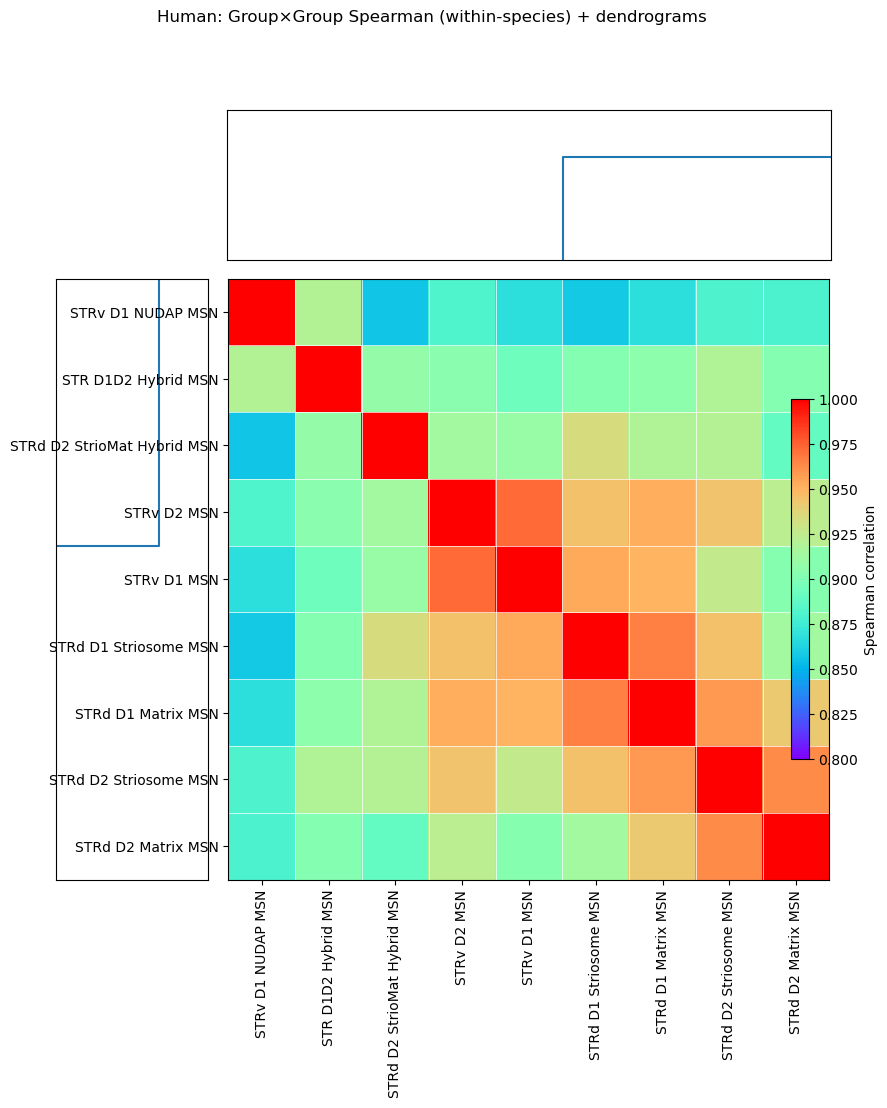

/scratch/fast/4134667/ipykernel_1669021/453438598.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


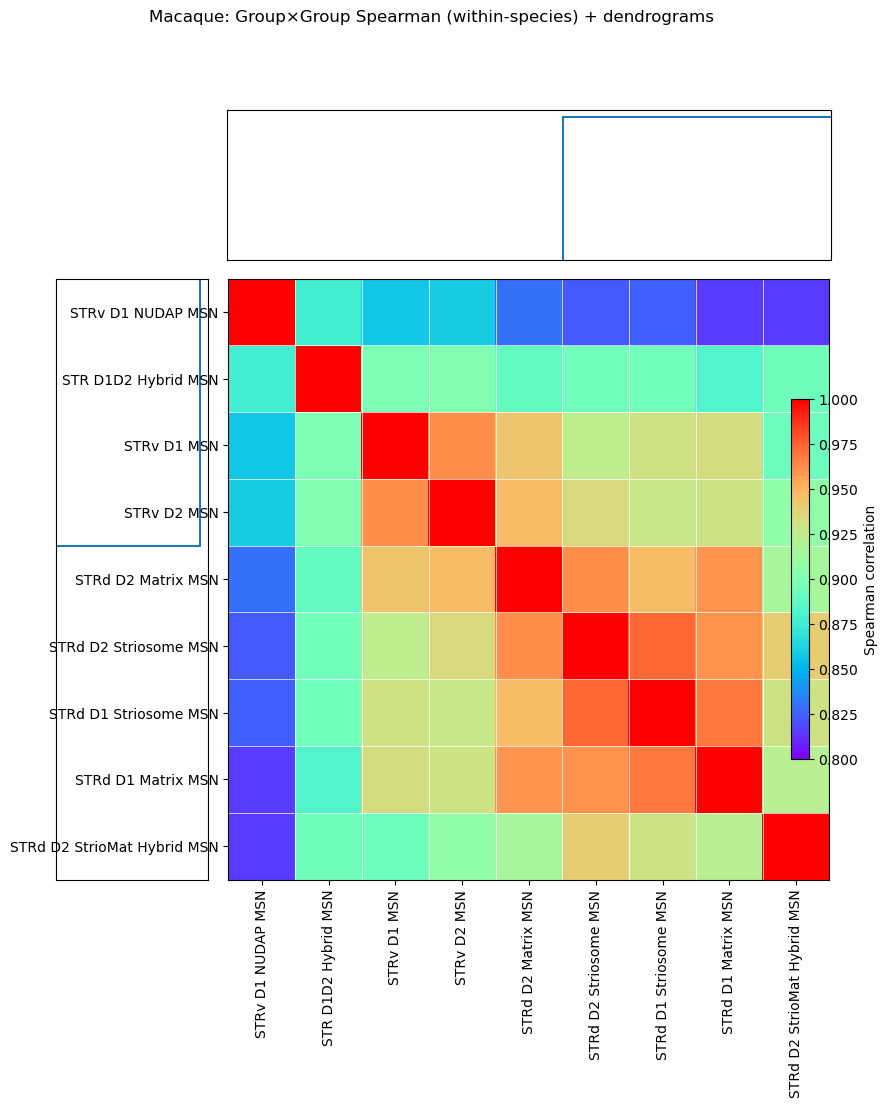

/scratch/fast/4134667/ipykernel_1669021/453438598.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


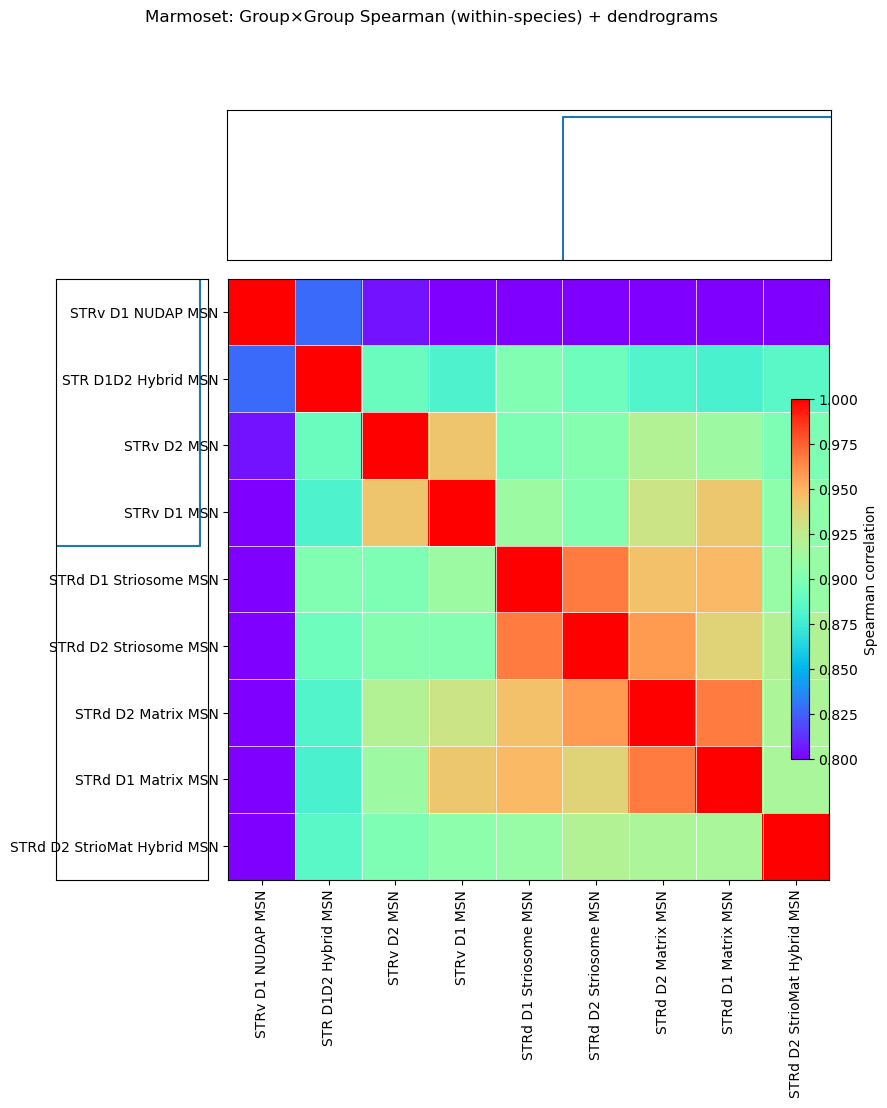

In [21]:
for spc, corr_df in corr_by_sp.items():
    plot_correlation_heatmap_with_dendrogram(
        corr_df,
        title=f"{spc}: Group×Group Spearman (within-species) + dendrograms",
        figsize=(10, 10),
        vmin=0.8, vmax=1,
        cmap="rainbow", #viridis
        annotate=False,
        linkage_method="average",
        optimal_ordering=True,
        output_file=None
    )


In [29]:
adata_msn_ds = downsample_per_cluster_donor(
    adata_msn,
    cluster_key="Cluster",
    donor_key="donor_id",
    max_cells_per_group=100,
    require_shared_donors=True,
    random_state=123  # reproducible
)


In [15]:
adata_msn_ds.obs.groupby(['Cluster', 'donor_id']).size().unstack(fill_value=0)

donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007,...,Q21.26.002,Q21.26.010,QM21.26.003,QM23.50.001,QM23.50.002,QM23.50.003,cjCroissant,cjJellybean,cjNutmeg,cjRambo
Cluster,,,,,,,,,,,,,,,,,,,,,
Human-2,81,0,150,500,258,53,232,500,305,397,...,0,0,0,0,0,0,0,0,0,0
Human-8,5,0,82,59,206,3,360,176,15,148,...,0,0,0,0,0,0,0,0,0,0
Human-9,16,0,193,49,366,8,500,141,51,319,...,0,0,0,0,0,0,0,0,0,0
Human-22,39,0,500,500,490,101,271,444,445,500,...,0,0,0,0,0,0,0,0,0,0
Human-23,103,0,169,215,37,500,26,58,454,19,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Marmoset-1222,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,13,500,450,0
Marmoset-1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,54,24,0
Marmoset-1228,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,98,37,0


In [30]:
adata_msn_human = adata_msn_ds[adata_msn_ds.obs["organism"].isin(['Human'])].copy()
adata_msn_macaque = adata_msn_ds[adata_msn_ds.obs["organism"].isin(['Macaque'])].copy()
adata_msn_marmoset = adata_msn_ds[adata_msn_ds.obs["organism"].isin(['Marmoset'])].copy()

In [31]:
print(adata_msn_human.shape)
print(adata_msn_macaque.shape)
print(adata_msn_marmoset.shape)

(66672, 16630)
(32941, 16630)
(25594, 16630)


### human

In [32]:
import scanpy as sc

In [47]:
sc.tl.rank_genes_groups(adata_msn_human, "hybrid_vs_classic", method="wilcoxon", corr_method = "benjamini-hochberg", pts=True, 
                        use_raw=False, groups= ["Hybrid"],reference="Classic", key_added="hybrid_vs_classic") #https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html


print(adata_msn_human.uns["hybrid_vs_classic"]["names"].dtype.names)
all_groups = adata_msn_human.uns["hybrid_vs_classic"]["names"].dtype.names

df_all = pd.concat([
    sc.get.rank_genes_groups_df(adata_msn_human, group=grp, key='hybrid_vs_classic').assign(group=grp)
    for grp in all_groups
])

display(df_all.head(30))
df_all.to_csv(work_dir + "/rank_genes_hybrid_vs_classic_DEGs_in_humanMSNs_ds.csv", index=False)
df_human= df_all.copy()

df_filtered = df_all[
    (df_all["group"] == "Hybrid") &
    (df_all['logfoldchanges'] > 1) &
    (df_all['pvals_adj'] < 0.01) &
    (df_all['pct_nz_group'] > 0.2)
]
df_human_filtered = df_filtered.copy()

('Hybrid',)


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,group
0,FOXP2,178.079147,7.941296,0.0,0.0,0.994019,Hybrid
1,LUZP2,175.301331,10.389394,0.0,0.0,0.986724,Hybrid
2,ERBB4,171.910492,3.391320,0.0,0.0,0.999416,Hybrid
3,ADARB2,171.160004,9.926647,0.0,0.0,0.979503,Hybrid
4,TSHZ1,169.935242,6.101737,0.0,0.0,0.973740,Hybrid
5,TRHDE,167.320190,8.432074,0.0,0.0,0.958421,Hybrid
6,SLC35F1,166.836395,4.870334,0.0,0.0,0.997155,Hybrid
7,GALNTL6,165.285477,3.268923,0.0,0.0,0.998614,Hybrid
8,EPHA6,159.103928,1.593939,0.0,0.0,0.998614,Hybrid
9,KCNJ3,158.460892,9.127285,0.0,0.0,0.899044,Hybrid


In [ ]:
df_human_filtered

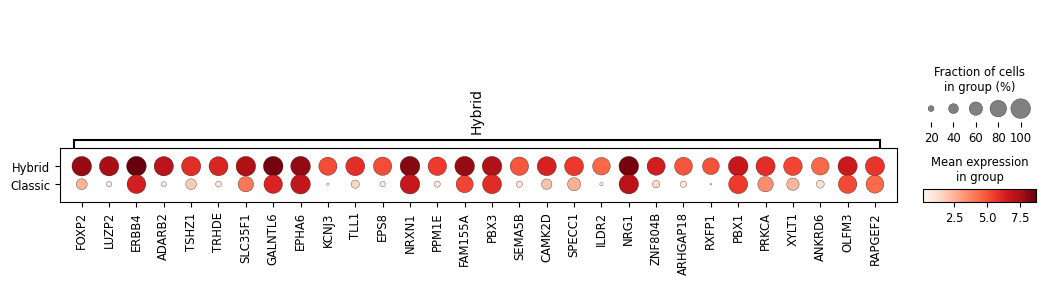

In [48]:
def top_genes_dict_from_df(df_filtered, top_n=10) -> dict:
    """
    Convert a filtered rank_genes_groups DataFrame into a var_names dictionary
    grouped by 'group', each with top N genes based on score.
    """
    top_genes_dict = {}
    for group, group_df in df_filtered.groupby("group"):
        top_genes = (
            group_df
            .sort_values("scores", ascending=False)
            .head(top_n)["names"]
            .tolist()
        )
        top_genes_dict[group] = top_genes
    return top_genes_dict
    

dict_df_filtered = top_genes_dict_from_df(df_human_filtered, top_n=30) # to show the gene patterns of filtered ones


sc.pl.dotplot(
    adata_msn_human,
    var_names=dict_df_filtered,
    groupby="hybrid_vs_classic", # groupby="GM_WM_location",
)

### macaque

In [33]:
sc.tl.rank_genes_groups(adata_msn_macaque, "hybrid_vs_classic", method="wilcoxon", corr_method = "benjamini-hochberg", pts=True, 
                        use_raw=False, groups= ["Hybrid"], reference="Classic", key_added="hybrid_vs_classic") #https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html


print(adata_msn_macaque.uns["hybrid_vs_classic"]["names"].dtype.names)
all_groups = adata_msn_macaque.uns["hybrid_vs_classic"]["names"].dtype.names

df_all = pd.concat([
    sc.get.rank_genes_groups_df(adata_msn_macaque, group=grp, key='hybrid_vs_classic').assign(group=grp)
    for grp in all_groups
])

display(df_all.head(30))
df_all.to_csv(work_dir + "/rank_genes_hybrid_vs_classic_DEGs_in_macaqueMSNs_ds.csv", index=False)
df_macaque= df_all.copy()

df_filtered = df_all[
    (df_all["group"] == "Hybrid") &
    (df_all['logfoldchanges'] > 1) &
    (df_all['pvals_adj'] < 0.01) &
    (df_all['pct_nz_group'] > 0.2)
]
df_macaque_filtered = df_filtered.copy()

('Hybrid',)


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,group
0,FOXP2,129.909134,6.914824,0.0,0.0,0.999001,Hybrid
1,GALNTL6,129.107651,5.788788,0.0,0.0,0.999126,Hybrid
2,ERBB4,126.669098,5.236412,0.0,0.0,0.997128,Hybrid
3,TSHZ1,122.412086,6.181649,0.0,0.0,0.965659,Hybrid
4,PBX3,113.468300,2.611110,0.0,0.0,0.997253,Hybrid
5,PPM1E,112.703766,6.624145,0.0,0.0,0.931194,Hybrid
6,FAM155A,110.692993,1.753496,0.0,0.0,0.999875,Hybrid
7,EYA2,106.622475,8.479856,0.0,0.0,0.811439,Hybrid
8,RXFP1,106.590187,10.218843,0.0,0.0,0.798202,Hybrid
9,KCNJ3,106.011848,6.934495,0.0,0.0,0.883242,Hybrid


In [34]:
df_macaque_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,group
0,FOXP2,129.909134,6.914824,0.000000e+00,0.000000e+00,0.999001,Hybrid
1,GALNTL6,129.107651,5.788788,0.000000e+00,0.000000e+00,0.999126,Hybrid
2,ERBB4,126.669098,5.236412,0.000000e+00,0.000000e+00,0.997128,Hybrid
3,TSHZ1,122.412086,6.181649,0.000000e+00,0.000000e+00,0.965659,Hybrid
4,PBX3,113.468300,2.611110,0.000000e+00,0.000000e+00,0.997253,Hybrid
...,...,...,...,...,...,...,...
724,CAPN2,12.818591,1.007096,1.290240e-37,9.942861e-37,0.255994,Hybrid
755,TRMO,12.178740,1.179842,4.034709e-34,2.966278e-33,0.205170,Hybrid
772,LRRC75A,11.956794,1.129945,5.982763e-33,4.316414e-32,0.210040,Hybrid
784,PLD5,11.717320,1.076759,1.039073e-31,7.306465e-31,0.247128,Hybrid


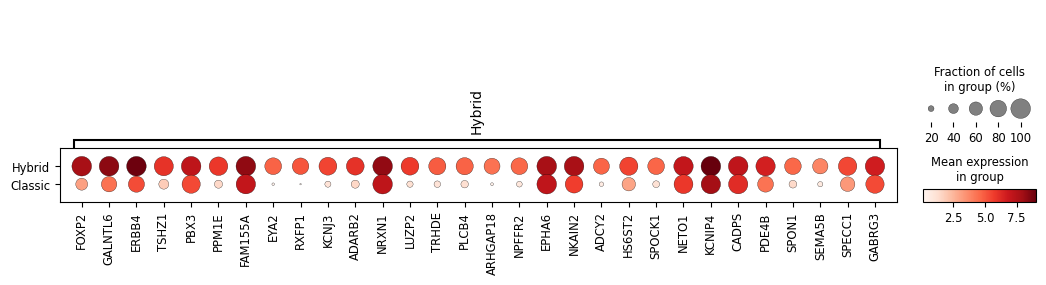

In [42]:
dict_df_filtered = top_genes_dict_from_df(df_macaque_filtered, top_n=30) # to show the gene patterns of filtered ones


sc.pl.dotplot(
    adata_msn_macaque,
    var_names=dict_df_filtered,
    groupby="hybrid_vs_classic", # groupby="GM_WM_location",
)

### marmoset

In [43]:
sc.tl.rank_genes_groups(adata_msn_marmoset, "hybrid_vs_classic", method="wilcoxon", corr_method = "benjamini-hochberg", pts=True, 
                        use_raw=False, groups= ["Hybrid"],reference="Classic", key_added="hybrid_vs_classic") #https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html


print(adata_msn_marmoset.uns["hybrid_vs_classic"]["names"].dtype.names)
all_groups = adata_msn_marmoset.uns["hybrid_vs_classic"]["names"].dtype.names

df_all = pd.concat([
    sc.get.rank_genes_groups_df(adata_msn_marmoset, group=grp, key='hybrid_vs_classic').assign(group=grp)
    for grp in all_groups
])

display(df_all.head(30))
df_all.to_csv(work_dir + "/rank_genes_hybrid_vs_classic_DEGs_in_marmosetMSNs_ds.csv", index=False)
df_marmoset= df_all.copy()

df_filtered = df_all[
    (df_all["group"] == "Hybrid") &
    (df_all['logfoldchanges'] > 1) &
    (df_all['pvals_adj'] < 0.01) &
    (df_all['pct_nz_group'] > 0.2)
]
df_marmoset_filtered = df_filtered.copy()


('Hybrid',)


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,group
0,ERBB4,114.202057,6.283837,0.0,0.0,0.999479,Hybrid
1,FOXP2,112.569633,7.363066,0.0,0.0,0.995830,Hybrid
2,GALNTL6,110.050980,5.405732,0.0,0.0,0.996525,Hybrid
3,KCNJ3,106.793961,8.546674,0.0,0.0,0.975851,Hybrid
4,TSHZ1,101.510826,6.208059,0.0,0.0,0.942495,Hybrid
5,NKAIN3,101.191895,8.945581,0.0,0.0,0.945796,Hybrid
6,SLC35F1,100.710815,5.362536,0.0,0.0,0.984017,Hybrid
7,ADARB2,100.622208,7.792326,0.0,0.0,0.955003,Hybrid
8,PPM1E,94.315285,7.084549,0.0,0.0,0.932071,Hybrid
9,CDH12,91.052727,5.976825,0.0,0.0,0.977936,Hybrid


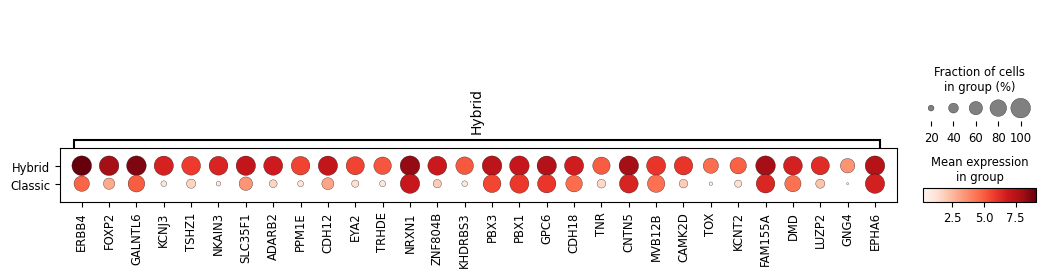

In [46]:
dict_df_filtered = top_genes_dict_from_df(df_marmoset_filtered, top_n=30) # to show the gene patterns of filtered ones


sc.pl.dotplot(
    adata_msn_marmoset,
    var_names=dict_df_filtered,
    groupby="hybrid_vs_classic", # groupby="GM_WM_location",
)

In [51]:
df_human_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,group
0,FOXP2,178.079147,7.941296,0.000000e+00,0.000000e+00,0.994019,Hybrid
1,LUZP2,175.301331,10.389394,0.000000e+00,0.000000e+00,0.986724,Hybrid
2,ERBB4,171.910492,3.391320,0.000000e+00,0.000000e+00,0.999416,Hybrid
3,ADARB2,171.160004,9.926647,0.000000e+00,0.000000e+00,0.979503,Hybrid
4,TSHZ1,169.935242,6.101737,0.000000e+00,0.000000e+00,0.973740,Hybrid
...,...,...,...,...,...,...,...
1106,HACD1,16.377193,1.089612,2.782923e-60,1.484761e-59,0.219783,Hybrid
1125,PDZRN3,16.111727,1.299469,2.110498e-58,1.104740e-57,0.202495,Hybrid
1157,SEL1L3,15.481467,1.017130,4.627955e-54,2.342145e-53,0.221460,Hybrid
1192,CADM4,15.108451,1.009762,1.424493e-51,7.048297e-51,0.208039,Hybrid


## Veen Plot of DEGs

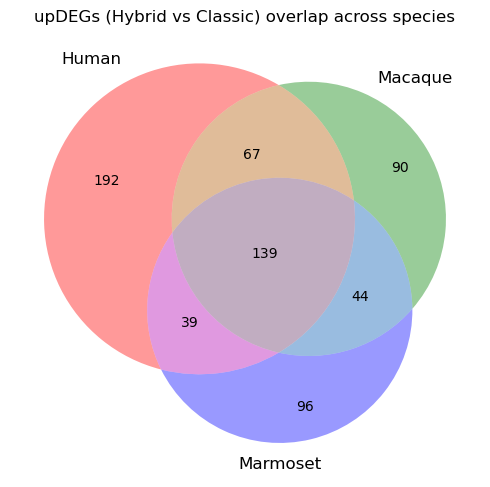

All three: 139
Human∩Macaque: 206
Human∩Marmoset: 178
Macaque∩Marmoset: 183


In [54]:
from matplotlib_venn import venn3

genes_h = set(df_human_filtered["names"])
genes_m = set(df_macaque_filtered["names"])
genes_mm = set(df_marmoset_filtered["names"])

plt.figure(figsize=(5,5))
venn3([genes_h, genes_m, genes_mm], set_labels=("Human","Macaque","Marmoset"))
plt.title("upDEGs (Hybrid vs Classic) overlap across species")
plt.tight_layout()
plt.show()


print("All three:", len(genes_h & genes_m & genes_mm))
print("Human∩Macaque:", len(genes_h & genes_m))
print("Human∩Marmoset:", len(genes_h & genes_mm))
print("Macaque∩Marmoset:", len(genes_m & genes_mm))


In [55]:
genes_human_only = genes_h - (genes_m | genes_mm)
genes_macaque_only = genes_m - (genes_h | genes_mm)
genes_marmoset_only = genes_mm - (genes_h | genes_m)


genes_human_macaque_shared = (genes_h & genes_m) - genes_mm
genes_human_marmoset_shared = (genes_h & genes_mm) - genes_m
genes_macaque_marmoset_shared = (genes_m & genes_mm) - genes_h


genes_shared_all_three = genes_h & genes_m & genes_mm


In [58]:
genes_human_only

{'ABCA1',
 'ABHD6',
 'ADAM32',
 'ADAM9',
 'ADAMTS10',
 'ADCY6',
 'AFAP1',
 'AFF2',
 'AHRR',
 'ANK1',
 'ANKRD29',
 'ARL6',
 'ATP1A3',
 'ATP8B4',
 'BAALC',
 'BACH1',
 'BAIAP3',
 'BICC1',
 'BLVRA',
 'C4H3orf33',
 'CADM4',
 'CALCOCO2',
 'CBLB',
 'CCDC152',
 'CDK5R1',
 'CEP112',
 'CHRM5',
 'CLEC2L',
 'COL28A1',
 'COL6A1',
 'COLGALT2',
 'CREG2',
 'CRHR1',
 'CRHR2',
 'CRTAC1',
 'CXCL14',
 'DDAH1',
 'DENND2A',
 'DIRAS3',
 'DISC1',
 'DNAH8',
 'DOC2B',
 'DRD1',
 'ELN',
 'EPDR1',
 'EPHA4',
 'ETS2',
 'FAM102B',
 'FAM107B',
 'FAM160A1',
 'FAM189A2',
 'FAM47E',
 'FBXO27',
 'FERMT2',
 'FGD4',
 'FGFR1',
 'FNIP2',
 'FOXN3',
 'FRAS1',
 'FRK',
 'FRMD3',
 'FXYD6',
 'FZD6',
 'GABRQ',
 'GALNT2',
 'GHR',
 'GNAI2',
 'GRAMD1B',
 'GRB14',
 'GRIK3',
 'GRIN2A',
 'GSAP',
 'HACD1',
 'HIPK2',
 'HPCAL1',
 'HS3ST1',
 'HS6ST1',
 'IFFO2',
 'INPP5B',
 'INSR',
 'IQGAP1',
 'IRS1',
 'JAG1',
 'KCNIP3',
 'KCNK13',
 'KIAA2012',
 'KIF21B',
 'KIT',
 'KLHL4',
 'LAMA2',
 'LECT2',
 'LHFPL6',
 'LIN7A',
 'LMNTD1',
 'LSM11',
 'LSM14A'

## TFs

In [61]:
df_tfs = pd.read_csv("/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/Human/BasalGanglia/analysis/f1" + "/TFs_lambert_pmid29425488_1.01.txt")
tf_genes = set(df_tfs["hgnc_symbol"]) 
#tf_genes

In [67]:
genes_human_only_tf = list(set(genes_human_only) & set(tf_genes))
print(genes_human_only_tf)


genes_shared_all_three_tf = list(set(genes_shared_all_three) & set(tf_genes))
print(genes_shared_all_three_tf)

['SOX1', 'MKX', 'BACH1', 'FOXN3', 'RXRG', 'ETS2', 'PRDM5', 'SOX11', 'ZNF496', 'ZBTB16', 'KCNIP3', 'AHRR']
['ZNF804B', 'CUX2', 'PBX3', 'ZNF608', 'PBX1', 'TSHZ1', 'FOXP2', 'NFIB', 'ETV6', 'HIVEP1', 'SOX2', 'NFIX']


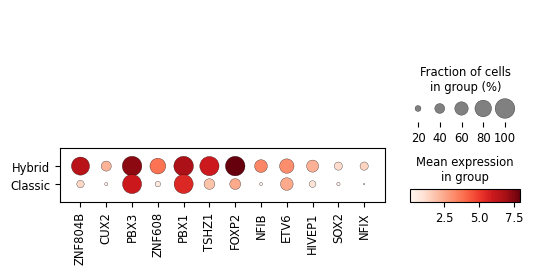

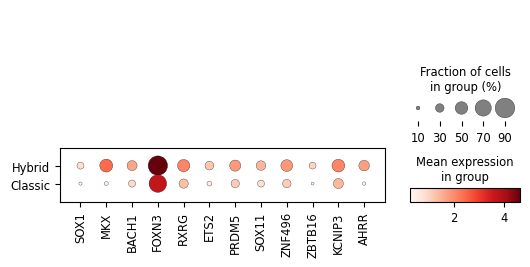

In [69]:
sc.pl.dotplot(
    adata_msn_human,
    var_names=genes_shared_all_three_tf,
    groupby="hybrid_vs_classic", # groupby="GM_WM_location",
)

sc.pl.dotplot(
    adata_msn_human,
    var_names=genes_human_only_tf,
    groupby="hybrid_vs_classic", # groupby="GM_WM_location",
)

In [ ]:
dict_df_filtered_tf = top_genes_dict_from_df(df_filtered_tf, top_n=30) # " df_filtered_tf " !!!! to show the gene patterns of filtered TF ones

sc.pl.rank_genes_groups_dotplot(
    adata,
    var_names=dict_df_filtered_tf, # filtered by " df_filtered_tf " 
    key="GM_WM_4_Subtypes", # groupby="GM_WM_location",
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    swap_axes=False,  
    colorbar_title='log fold change',
    figsize=(15,1.5),
)

## GO of overlapped Hybrids up-regulated genes

## GO of human-specific Hybrids up-regulated genes